# Excluded Subjects Diagnostic: Behavior of QC-Failed Participants
Compare RTs, accuracy, and probe performance between QC-passing and QC-excluded participants; per-subject detail for each exclusion.

## Table of Contents
1. Sample composition & status assignment
2. Within-subject CI helper
3. Go RT — simple stop and dual-task, by status
4. Probe RT — overall and by WM load, by status
5. Accuracy distributions — go choice and probe by load, by status
6. Per-excluded-subject detail (RT distributions + flagged metrics)

In [1]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import scipy.stats as stats

from stop_wm.config import ProjectConfig

# Initialize config — go up one level from notebooks/ to project root
project_root = Path.cwd().parent
config = ProjectConfig(project_root=project_root)

# Pathing — uses the *pre*-QC files so excluded subjects are still included
trials_wm_path  = config.results_dir / 'all_participants_reshaped_data_stop_signal_wm_task_e3.csv'
trials_ss_path  = config.results_dir / 'all_participants_reshaped_data_simple_stop_signal_e3.csv'
metrics_wm_path = config.results_dir / 'stop_signal_wm_task_e3_metrics.csv'
metrics_ss_path = config.results_dir / 'simple_stop_signal_e3_metrics.csv'
flag_wm_path    = config.results_dir / 'stop_signal_wm_task_metrics__flagged.csv'
flag_ss_path    = config.results_dir / 'stop_signal_metrics__flagged.csv'

# Load data
trials_wm = pd.read_csv(trials_wm_path, low_memory=False)
trials_ss = pd.read_csv(trials_ss_path, low_memory=False)
metrics_wm = pd.read_csv(metrics_wm_path)
metrics_ss = pd.read_csv(metrics_ss_path)
flag_wm = pd.read_csv(flag_wm_path)
flag_ss = pd.read_csv(flag_ss_path)

# Status assignment per subject — EXCLUDE if flagged in either task, otherwise PASS
flagged_ids = set(flag_ss['prolific_id']) | set(flag_wm['prolific_id'])
all_ids = sorted(set(metrics_ss['prolific_id']) | set(metrics_wm['prolific_id']))

status_df = pd.DataFrame({
    'prolific_id': all_ids,
    'status': ['EXCLUDE' if p in flagged_ids else 'PASS' for p in all_ids],
})

# Status columns on metrics + trial frames (trial frames use 'participant_id')
metrics_wm = metrics_wm.merge(status_df, on='prolific_id', how='left')
metrics_ss = metrics_ss.merge(status_df, on='prolific_id', how='left')
trials_wm['status'] = trials_wm['participant_id'].map(dict(zip(status_df.prolific_id, status_df.status)))
trials_ss['status'] = trials_ss['participant_id'].map(dict(zip(status_df.prolific_id, status_df.status)))

# Color scheme for status (PASS = blue, EXCLUDE = red)
STATUS_COLORS = {'PASS': '#2E86AB', 'EXCLUDE': '#C1121F'}

print('='*70)
print('SAMPLE COMPOSITION')
print('='*70)
print(status_df['status'].value_counts().to_string())
print(f"\nTotal approved: {len(status_df)}")
print(f"Flagged in simple SS only:    {len(set(flag_ss['prolific_id']) - set(flag_wm['prolific_id']))}")
print(f"Flagged in WM dual-task only: {len(set(flag_wm['prolific_id']) - set(flag_ss['prolific_id']))}")
print(f"Flagged in BOTH:              {len(set(flag_ss['prolific_id']) & set(flag_wm['prolific_id']))}")

Key STOPWM_DATADIR not found in /Users/lyndefolsom/research/working_memory_inhibition/experiment_3/.env.


Key STOPWM_RAWDATADIR not found in /Users/lyndefolsom/research/working_memory_inhibition/experiment_3/.env.


SAMPLE COMPOSITION
status
PASS       66
EXCLUDE    29

Total approved: 95
Flagged in simple SS only:    2
Flagged in WM dual-task only: 19
Flagged in BOTH:              8


## 2. Within-subject CI helper
Cousineau (2005) + Morey (2008) within-subject 95% confidence intervals for repeated-measures plots.

In [ ]:
from stop_wm.within_subject_ci import calculate_within_subject_ci


## 3. Go RT — simple stop and dual-task, by status
Distributions of subject-mean go RTs split by QC status. Histograms with mean & median markers, plus a side-by-side comparison.

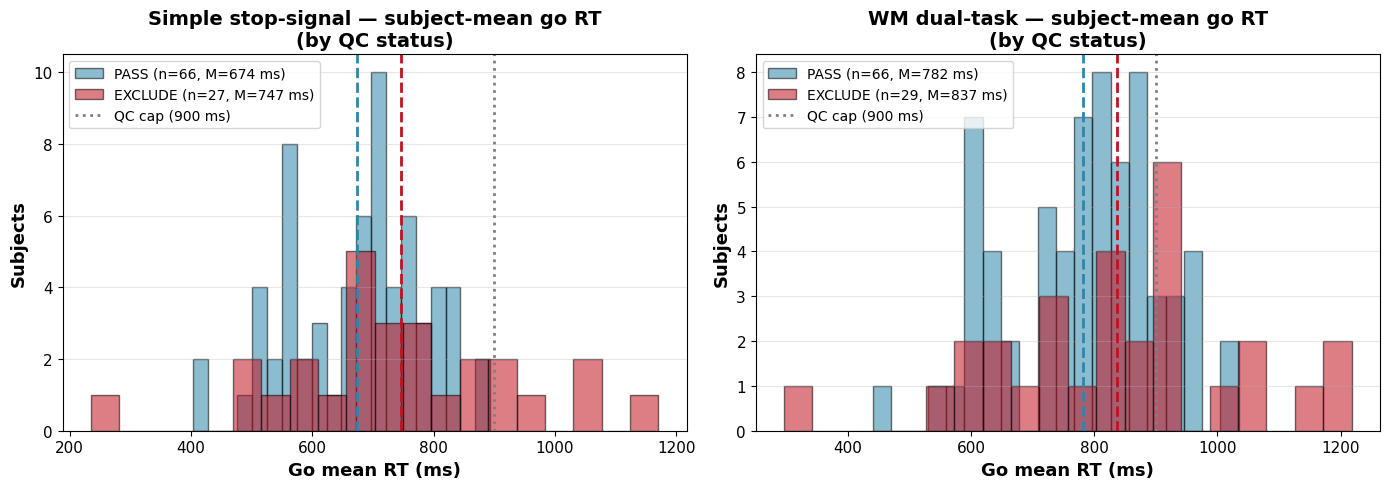

WELCH T-TESTS — go RT, EXCLUDE vs PASS
  Simple SS go_mean_rt                : t= 1.792, p=0.0824, d=+0.45 (EXCLUDE M=747, PASS M=674)
  WM   dual_task_go_mean_rt           : t= 1.352, p=0.1844, d=+0.33 (EXCLUDE M=837, PASS M=782)


In [3]:
# === SIMPLE STOP-SIGNAL: subject-mean go RTs ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task_label, df_metrics, col in [
    (axes[0], 'Simple stop-signal', metrics_ss, 'go_mean_rt'),
    (axes[1], 'WM dual-task',       metrics_wm, 'dual_task_go_mean_rt'),
]:
    for st in ['PASS','EXCLUDE']:
        vals = df_metrics.loc[df_metrics['status']==st, col].dropna()
        ax.hist(vals, bins=20, alpha=0.55, color=STATUS_COLORS[st], edgecolor='black',
                label=f"{st} (n={len(vals)}, M={vals.mean():.0f} ms)")
        ax.axvline(vals.mean(), color=STATUS_COLORS[st], linestyle='--', linewidth=2)
    ax.axvline(900, color='gray', linestyle=':', linewidth=2, label='QC cap (900 ms)')
    ax.set_title(f"{task_label} — subject-mean go RT\n(by QC status)", fontsize=14, fontweight='bold')
    ax.set_xlabel('Go mean RT (ms)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Subjects', fontsize=13, fontweight='bold')
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Group comparison stats (Welch t-test, since variances often unequal)
print("="*70)
print("WELCH T-TESTS — go RT, EXCLUDE vs PASS")
print("="*70)
for task_label, df_metrics, col in [
    ('Simple SS go_mean_rt', metrics_ss, 'go_mean_rt'),
    ('WM   dual_task_go_mean_rt', metrics_wm, 'dual_task_go_mean_rt'),
]:
    a = df_metrics.loc[df_metrics['status']=='EXCLUDE', col].dropna()
    b = df_metrics.loc[df_metrics['status']=='PASS',    col].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    pooled_sd = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    d = (a.mean() - b.mean()) / pooled_sd if pooled_sd else np.nan
    print(f"  {task_label:36s}: t={t:6.3f}, p={p:.4f}, d={d:+.2f} "
          f"(EXCLUDE M={a.mean():.0f}, PASS M={b.mean():.0f})")

## 4. Probe RT — overall and by WM load, by status
Memory probe response times. Per-load plot uses within-subject CIs for the PASS group; EXCLUDE shown as overlay points.

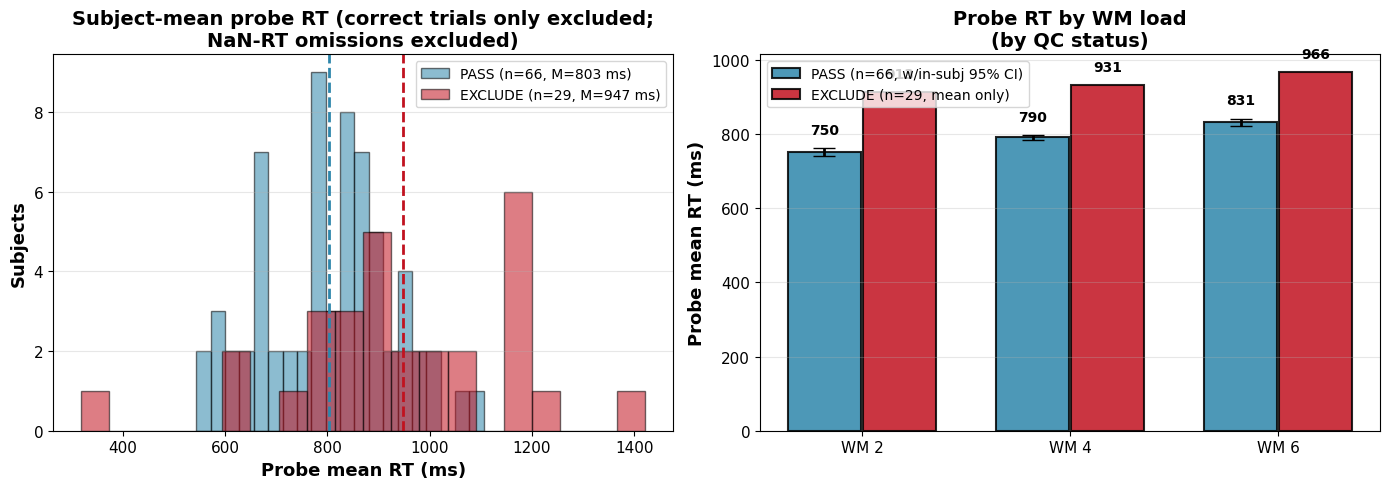

In [4]:
# === PROBE RT BY LOAD ===
loads = [2, 4, 6]
rt_cols = [f'probe_wm{w}_mean_rt' for w in loads]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) overall probe RT histogram by status
ax = axes[0]
trials_wm['memory_recognition_rt'] = pd.to_numeric(trials_wm['memory_recognition_rt'], errors='coerce')
subj_probe_rt = trials_wm.dropna(subset=['memory_recognition_rt']).groupby(['participant_id','status'])['memory_recognition_rt'].mean().reset_index()
for st in ['PASS','EXCLUDE']:
    v = subj_probe_rt.loc[subj_probe_rt['status']==st, 'memory_recognition_rt']
    ax.hist(v, bins=20, alpha=0.55, color=STATUS_COLORS[st], edgecolor='black',
            label=f"{st} (n={len(v)}, M={v.mean():.0f} ms)")
    ax.axvline(v.mean(), color=STATUS_COLORS[st], linestyle='--', linewidth=2)
ax.set_title('Subject-mean probe RT (correct trials only excluded;\nNaN-RT omissions excluded)', fontsize=14, fontweight='bold')
ax.set_xlabel('Probe mean RT (ms)', fontsize=13, fontweight='bold')
ax.set_ylabel('Subjects', fontsize=13, fontweight='bold')
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=10)

# (b) probe RT by load (PASS bars w/ within-subject CIs; EXCLUDE means as overlay)
ax = axes[1]
pass_mat = metrics_wm.loc[metrics_wm['status']=='PASS', rt_cols].dropna()
exc_mat  = metrics_wm.loc[metrics_wm['status']=='EXCLUDE', rt_cols].dropna()
pass_means = pass_mat.mean().values
pass_cis = calculate_within_subject_ci(pass_mat)
exc_means = exc_mat.mean().values

x = np.arange(len(loads))
load_colors = ['#2E86AB', '#A23B72', '#F18F01']
ax.bar(x - 0.18, pass_means, 0.35, yerr=pass_cis, capsize=8, alpha=0.85,
       color=STATUS_COLORS['PASS'], edgecolor='black', linewidth=1.5,
       error_kw={'linewidth':2,'ecolor':'black'}, label=f"PASS (n={len(pass_mat)}, w/in-subj 95% CI)")
ax.bar(x + 0.18, exc_means, 0.35, alpha=0.85,
       color=STATUS_COLORS['EXCLUDE'], edgecolor='black', linewidth=1.5,
       label=f"EXCLUDE (n={len(exc_mat)}, mean only)")
for xi, m_p, c_p in zip(x, pass_means, pass_cis):
    ax.text(xi - 0.18, m_p + c_p + 30, f'{m_p:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for xi, m_e in zip(x, exc_means):
    ax.text(xi + 0.18, m_e + 30, f'{m_e:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'WM {w}' for w in loads])
ax.set_title('Probe RT by WM load\n(by QC status)', fontsize=14, fontweight='bold')
ax.set_ylabel('Probe mean RT (ms)', fontsize=13, fontweight='bold')
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 5. Accuracy distributions — go choice and probe by load, by status
Probe accuracy (commission + omission count as wrong, per `subjectwise_metrics.py`) is the dominant driver of WM-task exclusion. Visualize the gap.

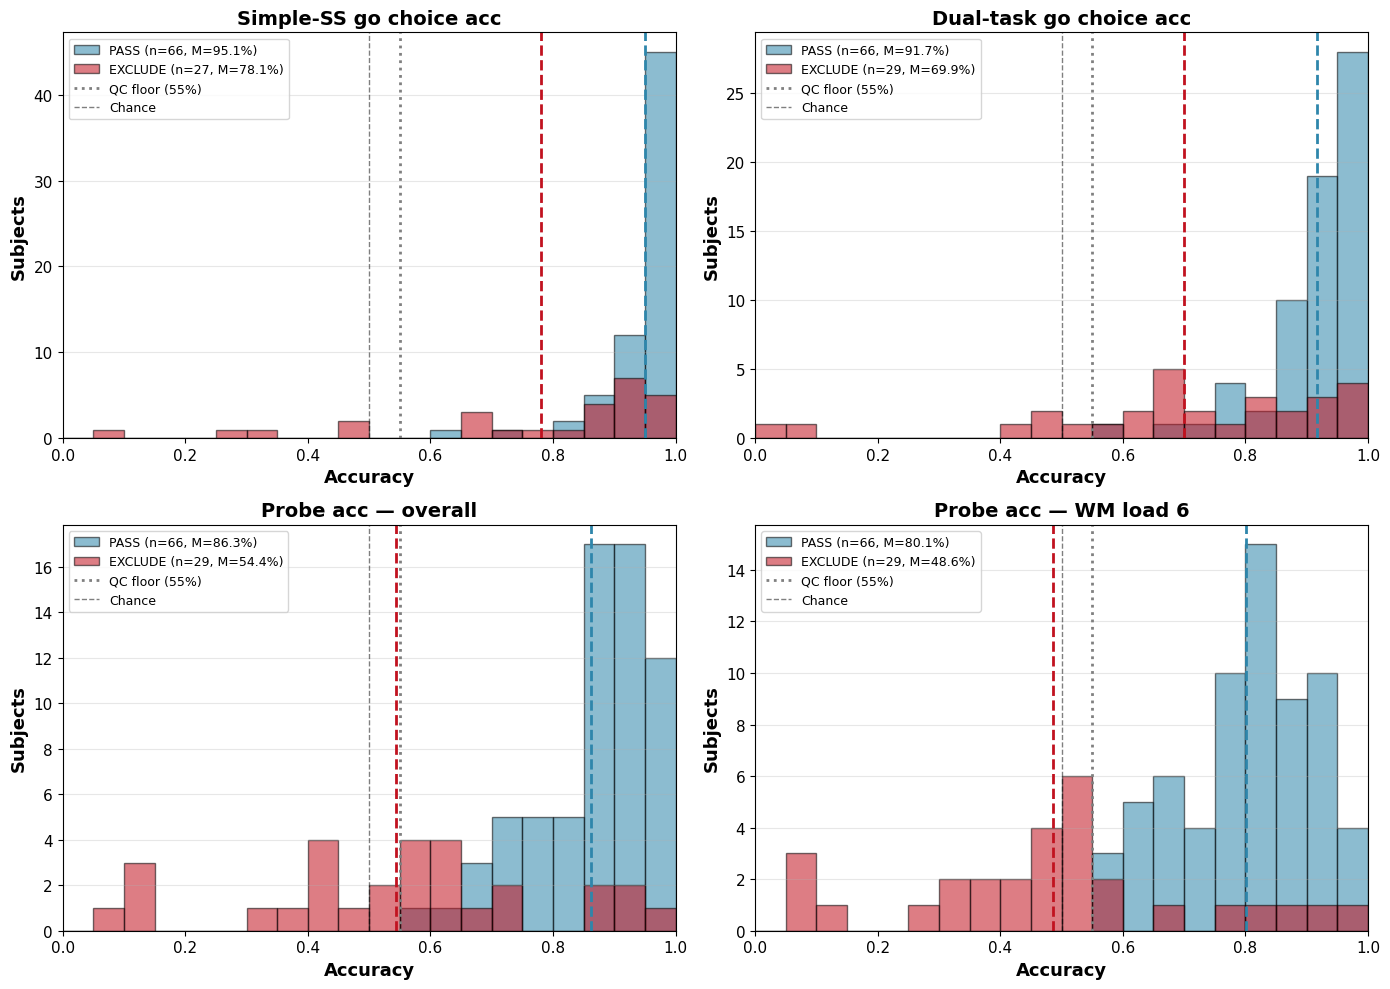

In [5]:
# === ACCURACY DISTRIBUTIONS ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

panels = [
    (axes[0,0], 'Simple-SS go choice acc', metrics_ss, 'go_choice_accuracy', 0.55),
    (axes[0,1], 'Dual-task go choice acc', metrics_wm, 'dual_task_go_choice_accuracy', 0.55),
    (axes[1,0], 'Probe acc — overall',     metrics_wm, 'probe_response_accuracy', 0.55),
    (axes[1,1], 'Probe acc — WM load 6',   metrics_wm, 'probe_wm6_response_accuracy', 0.55),
]
for ax, label, dfm, col, qc_floor in panels:
    for st in ['PASS','EXCLUDE']:
        v = dfm.loc[dfm['status']==st, col].dropna()
        ax.hist(v, bins=np.linspace(0,1,21), alpha=0.55, color=STATUS_COLORS[st],
                edgecolor='black', label=f"{st} (n={len(v)}, M={v.mean()*100:.1f}%)")
        ax.axvline(v.mean(), color=STATUS_COLORS[st], linestyle='--', linewidth=2)
    ax.axvline(qc_floor, color='gray', linestyle=':', linewidth=2, label=f'QC floor ({qc_floor*100:.0f}%)')
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Chance')
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_xlabel('Accuracy', fontsize=13, fontweight='bold')
    ax.set_ylabel('Subjects', fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Per-excluded-subject detail
For each EXCLUDE participant: trial-level RT distributions (go RT in dual-task, probe RT) and the literal exclusion reasons emitted by `flag_to_exclude.py`. Useful for visually inspecting whether a subject is, e.g., responding too fast (impulsive), too slow (timing out), or never responding (omitting).

Subject 5bef64b3  (full id: 5bef64b373e44f0001092811)
  Simple SS reasons:
    - stop_inhibition_success_rate (0.017) < min (0.25)
    - stop_fail_rate [BINOMIAL TEST] (0.983) >= max (0.633)
  WM dual-task reasons:
    - probe_wm6_response_accuracy (0.535) < min (0.55)


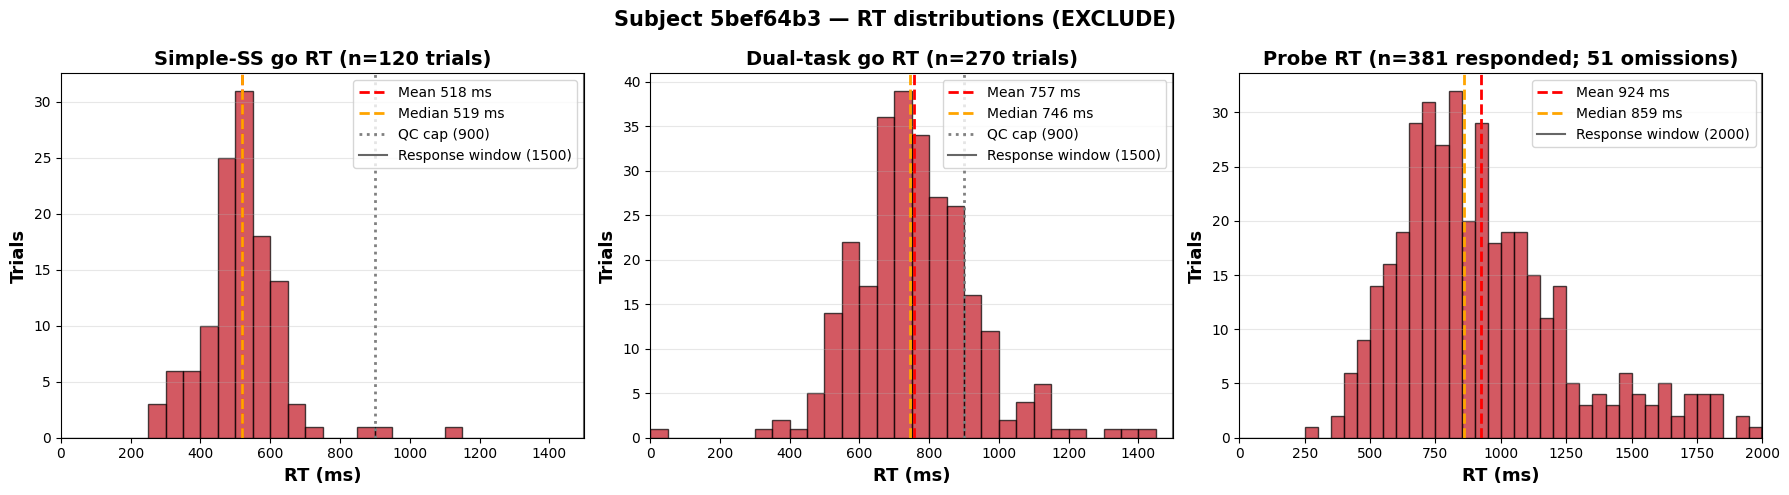

Subject 5c1c2c51  (full id: 5c1c2c51e2d9150001b5737e)
  WM dual-task reasons:
    - probe_response_accuracy (0.127) < min (0.55)
    - probe_wm2_response_accuracy (0.160) < min (0.55)
    - probe_wm4_response_accuracy (0.111) < min (0.55)
    - probe_wm6_response_accuracy (0.111) < min (0.55)


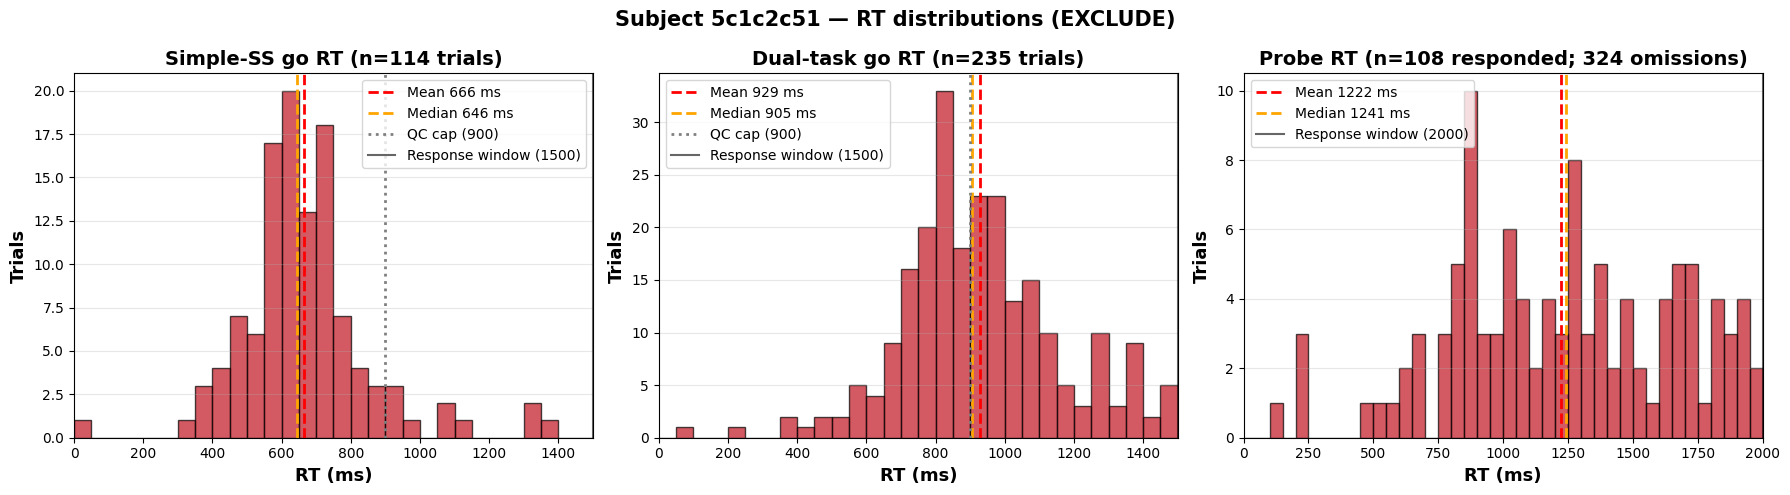

Subject 5d9b7c7e  (full id: 5d9b7c7efaa2860364b16476)
  Simple SS reasons:
    - go_mean_rt (936.110) > max (900.0)


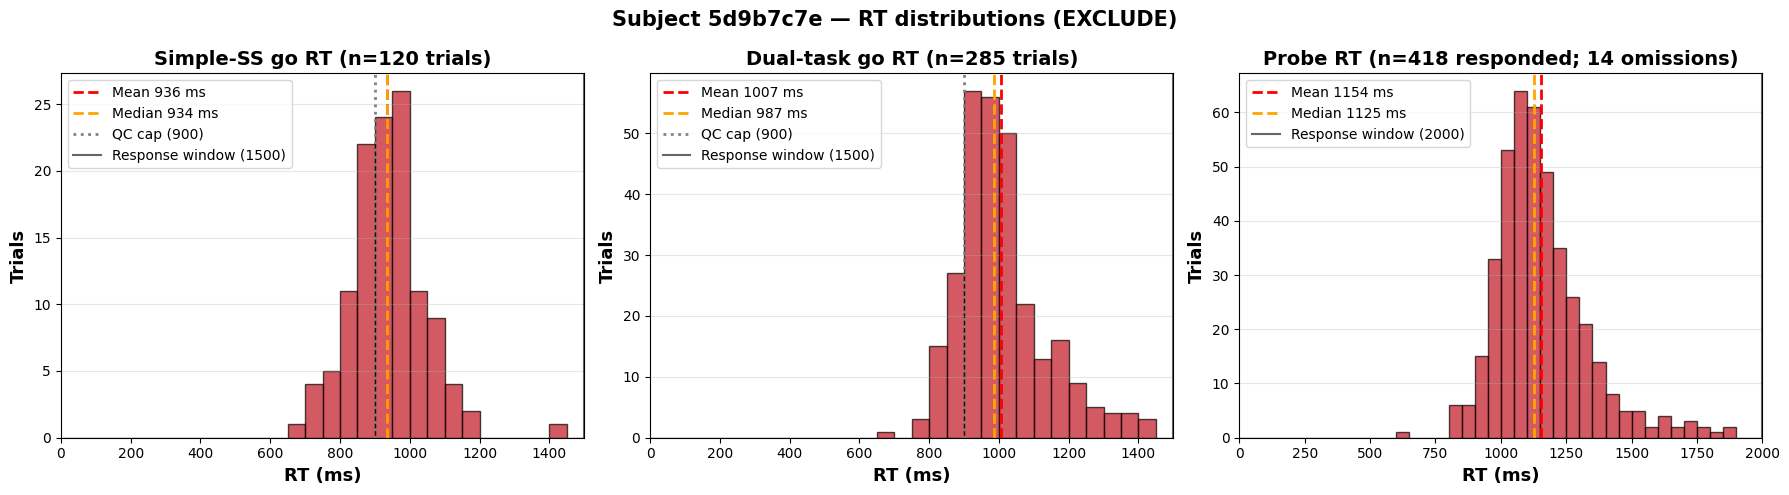

Subject 61647de7  (full id: 61647de75314468d5cb57f93)
  WM dual-task reasons:
    - probe_response_accuracy (0.493) < min (0.55)
    - probe_wm2_response_accuracy (0.535) < min (0.55)
    - probe_wm4_response_accuracy (0.472) < min (0.55)
    - probe_wm6_response_accuracy (0.472) < min (0.55)


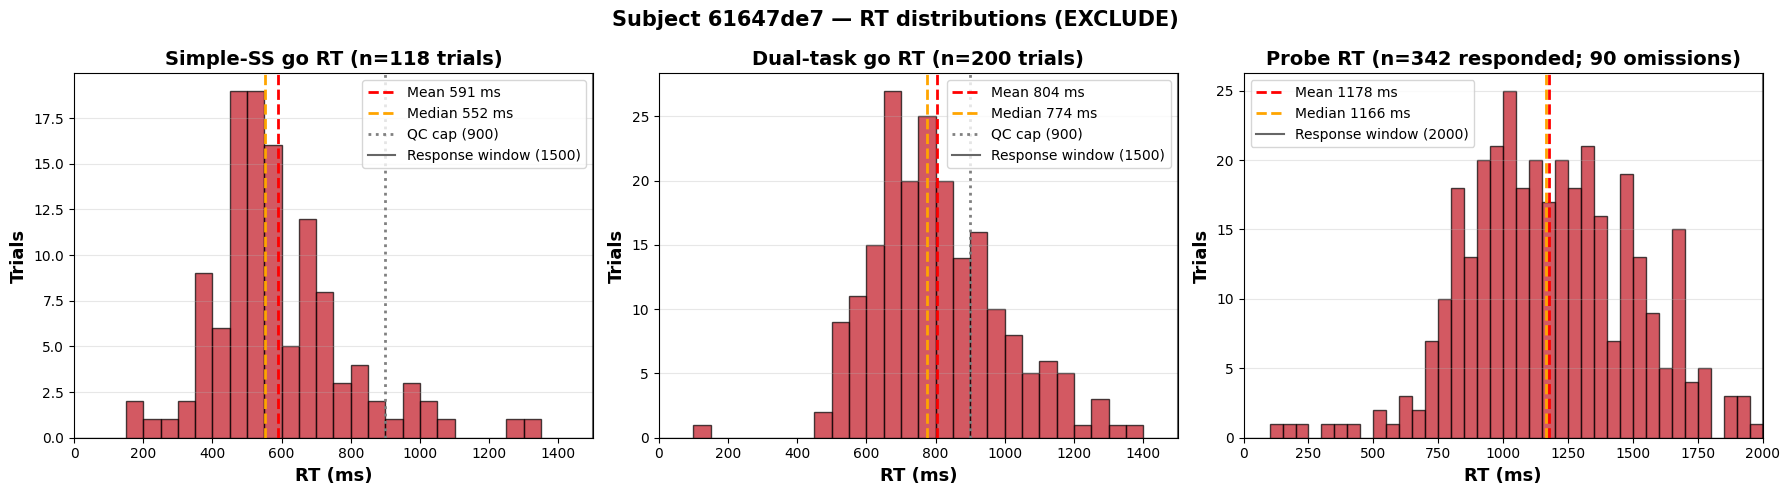

Subject 63474e67  (full id: 63474e67a5fd298c6103c409)
  WM dual-task reasons:
    - probe_response_accuracy (0.319) < min (0.55)
    - probe_wm2_response_accuracy (0.347) < min (0.55)
    - probe_wm4_response_accuracy (0.326) < min (0.55)
    - probe_wm6_response_accuracy (0.285) < min (0.55)


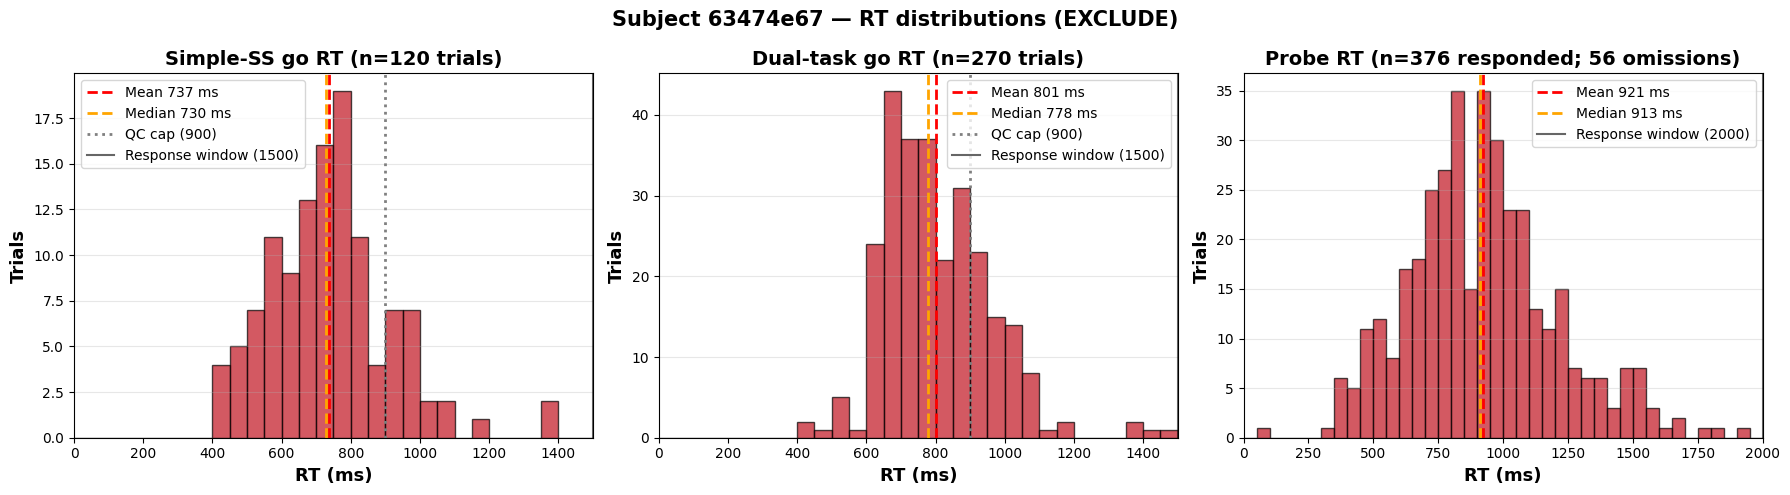

Subject 6623d91f  (full id: 6623d91f14f7871134e8ad01)
  WM dual-task reasons:
    - probe_wm6_response_accuracy (0.507) < min (0.55)


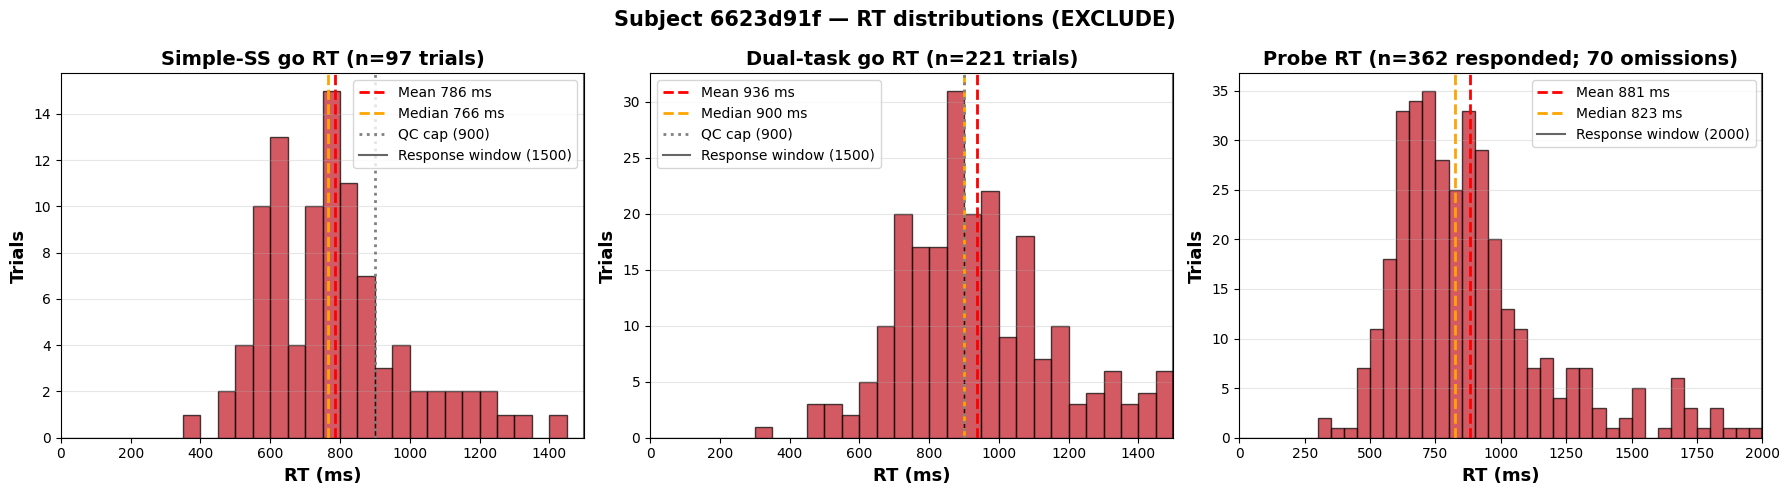

Subject 663e2e8a  (full id: 663e2e8a4c7d721dca2aa866)
  Simple SS reasons:
    - go_mean_rt (922.136) > max (900.0)


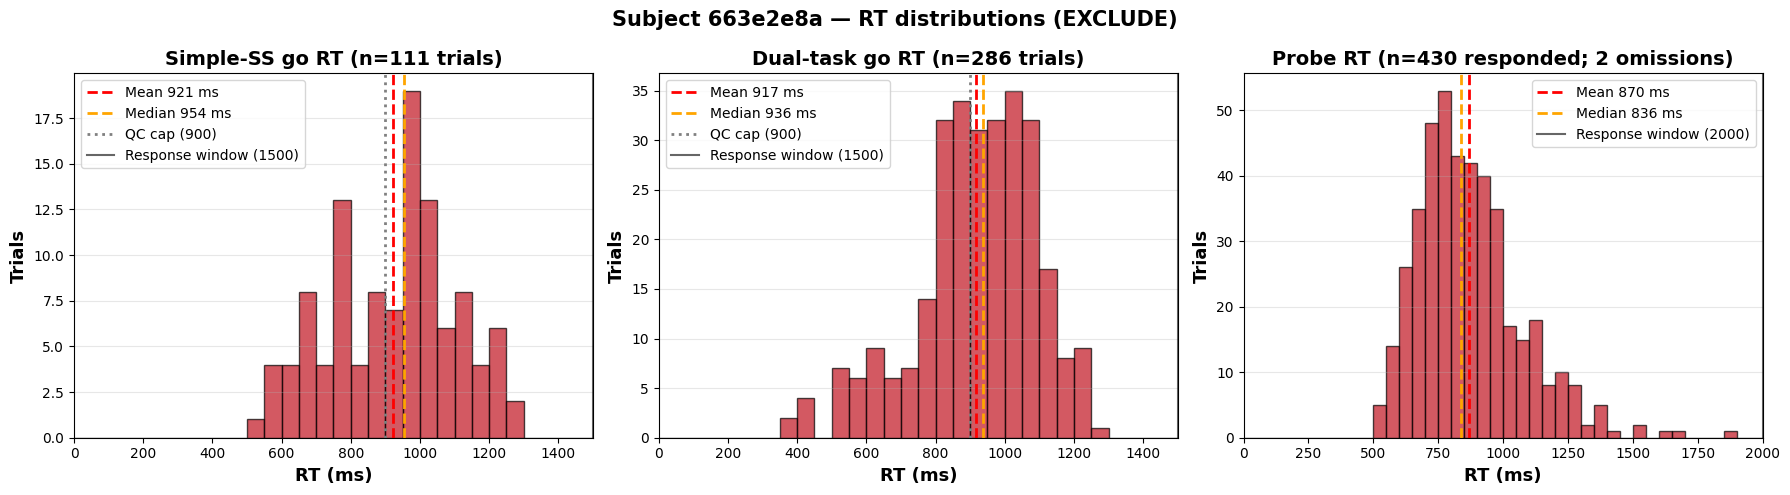

Subject 665a234c  (full id: 665a234c97c127c4605a9be1)
  WM dual-task reasons:
    - probe_wm4_response_accuracy (0.549) < min (0.55)


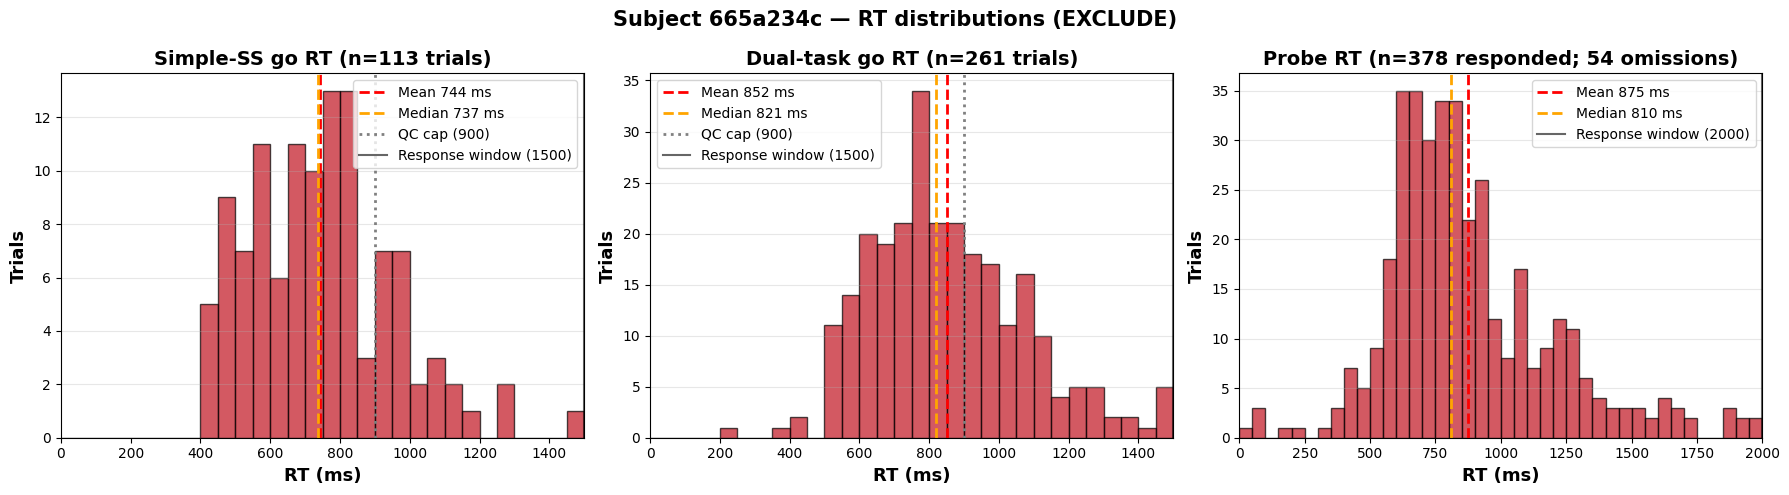

Subject 66ef8c16  (full id: 66ef8c16db6307178a651f0a)
  WM dual-task reasons:
    - probe_response_accuracy (0.535) < min (0.55)
    - probe_wm4_response_accuracy (0.528) < min (0.55)
    - probe_wm6_response_accuracy (0.493) < min (0.55)


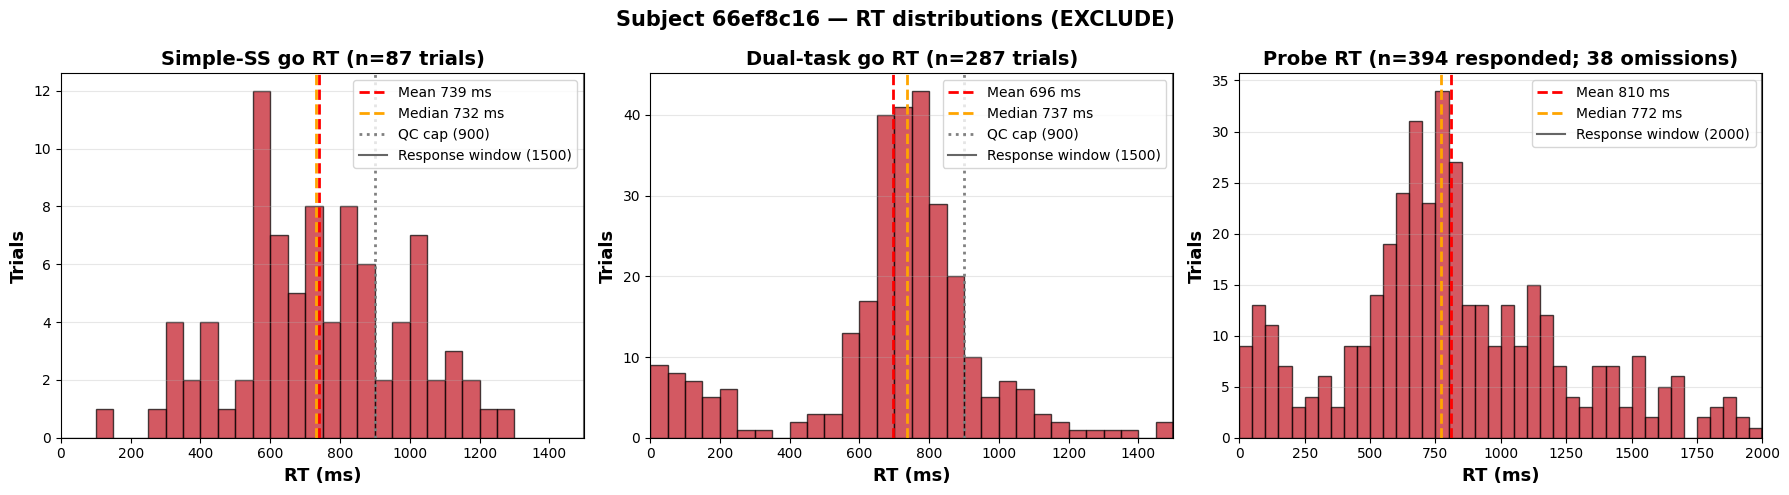

Subject 67241354  (full id: 672413541a4832a40147dec7)
  Simple SS reasons:
    - go_choice_accuracy (0.475) < min (0.55)
    - go_omission_rate (0.525) > max (0.5)
  WM dual-task reasons:
    - dual_task_go_choice_accuracy (0.483) < min (0.55)


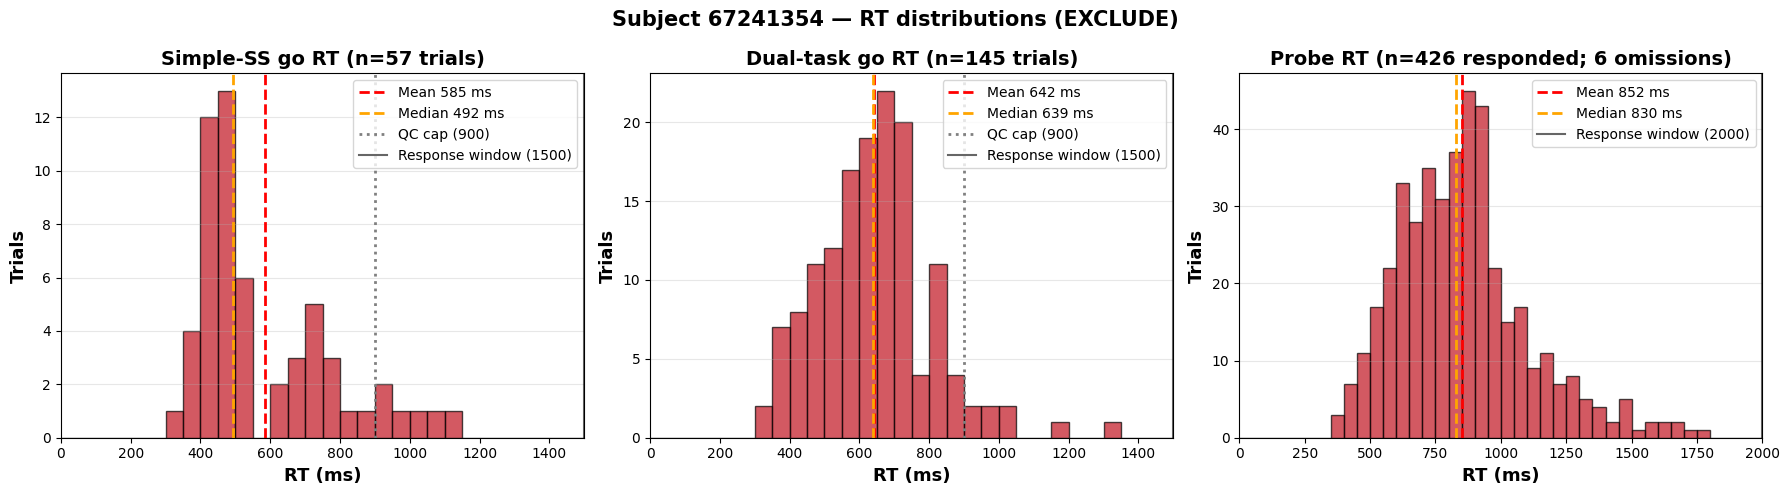

Subject 67aad067  (full id: 67aad067b49c4688a6459b1b)
  WM dual-task reasons:
    - probe_wm6_response_accuracy (0.507) < min (0.55)


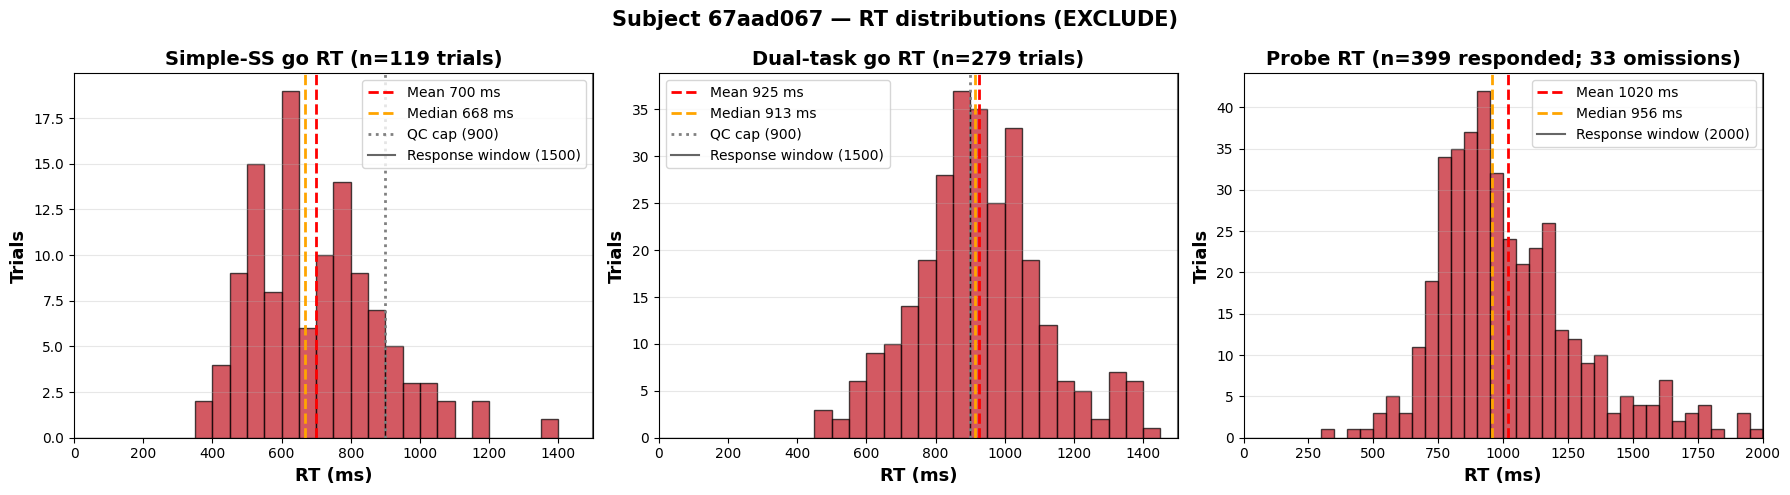

Subject 67cc82d7  (full id: 67cc82d73c1dc6dab0da3147)
  WM dual-task reasons:
    - probe_wm6_response_accuracy (0.417) < min (0.55)


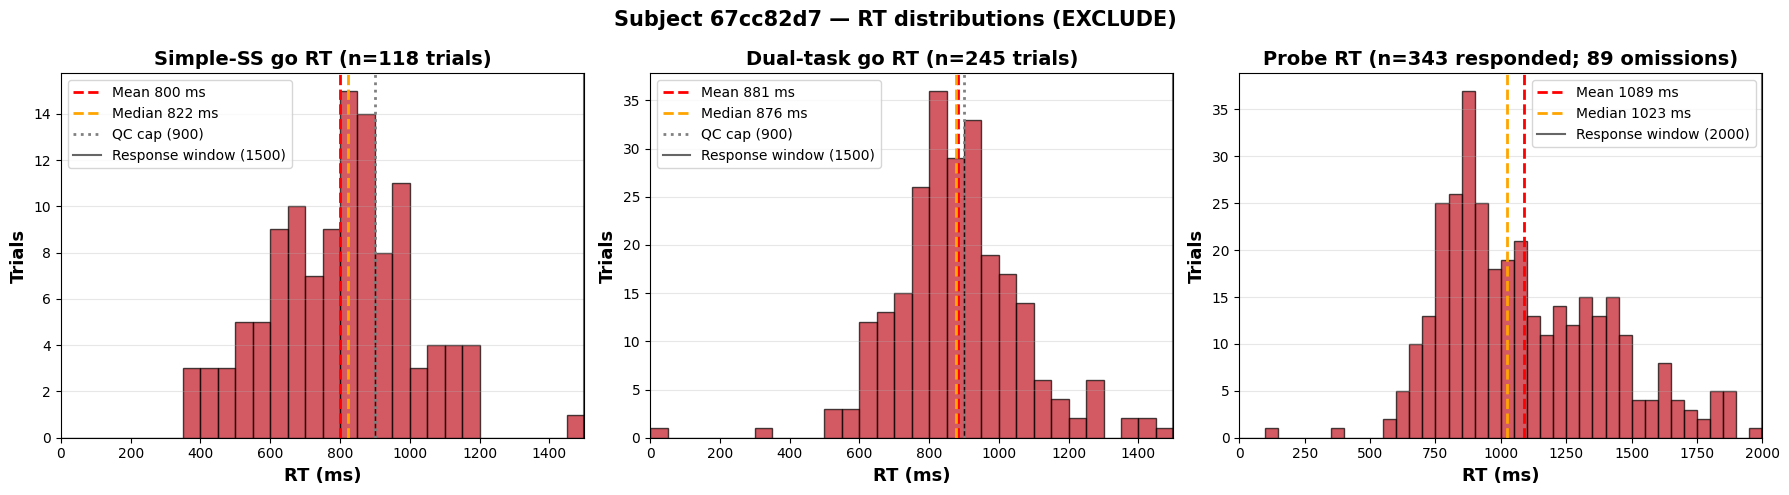

Subject 67e40624  (full id: 67e406244bfad9999a051c1e)
  Simple SS reasons:
    - go_mean_rt (1048.697) > max (900.0)
  WM dual-task reasons:
    - probe_response_accuracy (0.523) < min (0.55)
    - probe_wm4_response_accuracy (0.542) < min (0.55)


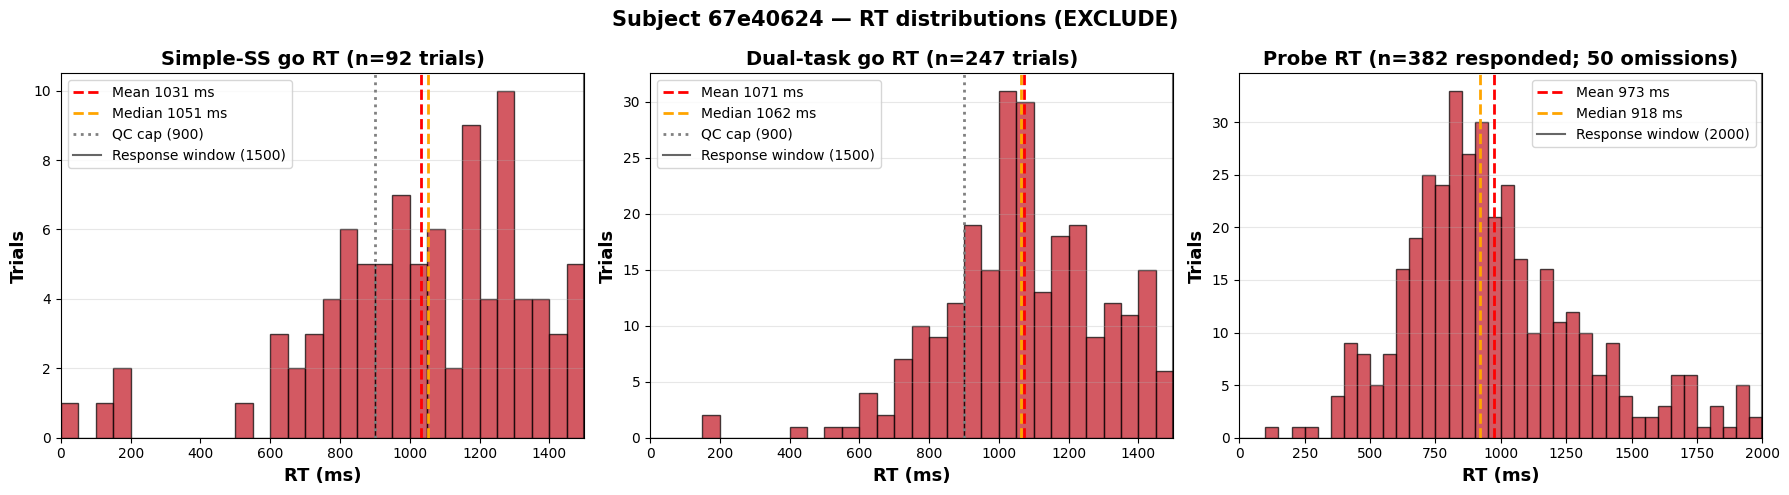

Subject 696e5a56  (full id: 696e5a56d7a7cb7e8de48ef8)
  Simple SS reasons:
    - go_choice_accuracy (0.275) < min (0.55)
    - go_mean_rt (938.364) > max (900.0)
  WM dual-task reasons:
    - dual_task_go_choice_accuracy (0.427) < min (0.55)
    - probe_wm6_response_accuracy (0.493) < min (0.55)


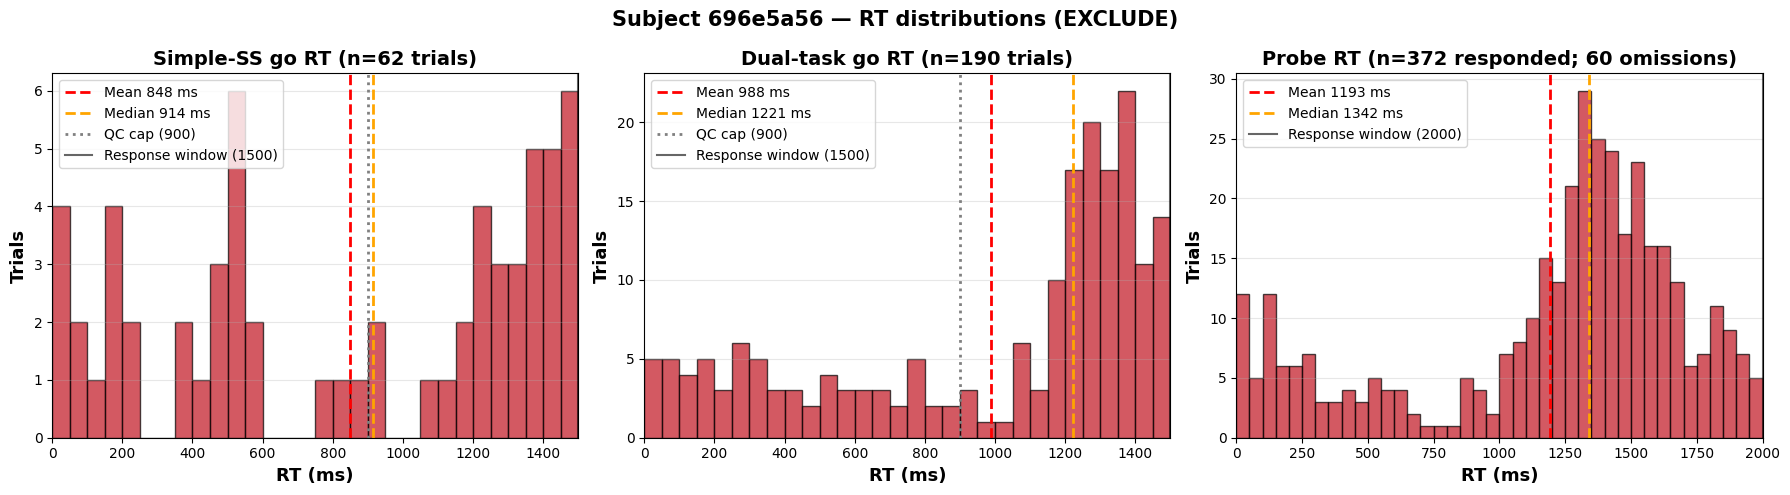

Subject 6983adf9  (full id: 6983adf91a057e752c11aa65)
  WM dual-task reasons:
    - dual_stop_fail_rate_wm2 [BINOMIAL TEST] (0.083) <= min (0.354)
    - dual_stop_fail_rate_wm4 [BINOMIAL TEST] (0.062) <= min (0.354)
    - dual_stop_fail_rate_wm6 [BINOMIAL TEST] (0.167) <= min (0.354)
    - dual_task_go_choice_accuracy (0.038) < min (0.55)
    - dual_task_stop_inhibition_success_rate (0.896) > max (0.75)
    - probe_response_accuracy (0.104) < min (0.55)
    - probe_wm2_response_accuracy (0.097) < min (0.55)
    - probe_wm4_response_accuracy (0.125) < min (0.55)
    - probe_wm6_response_accuracy (0.090) < min (0.55)
    - dual_task_go_omission_rate (0.913) > max (0.5)


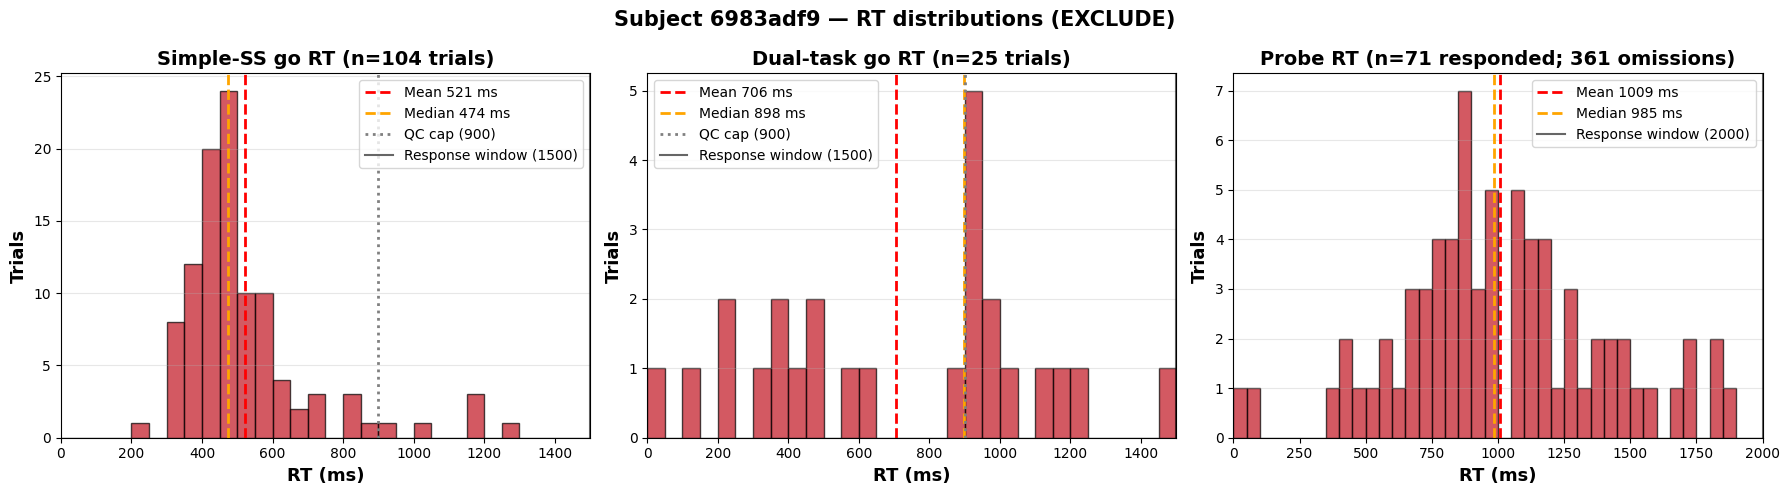

Subject 698ce4ba  (full id: 698ce4ba931f89581ecc6d7d)
  WM dual-task reasons:
    - dual_stop_fail_rate_wm6 [BINOMIAL TEST] (0.333) <= min (0.354)


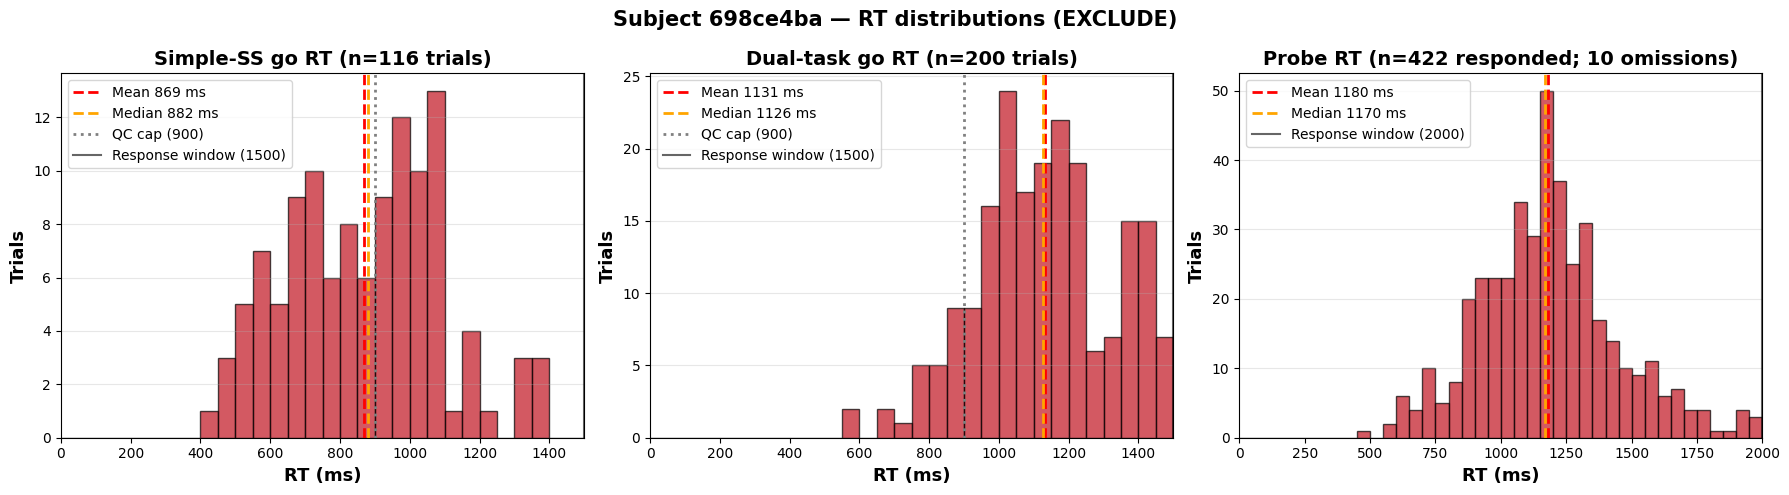

Subject 69972cda  (full id: 69972cda9a2b697e924fe91b)
  WM dual-task reasons:
    - probe_wm6_response_accuracy (0.514) < min (0.55)


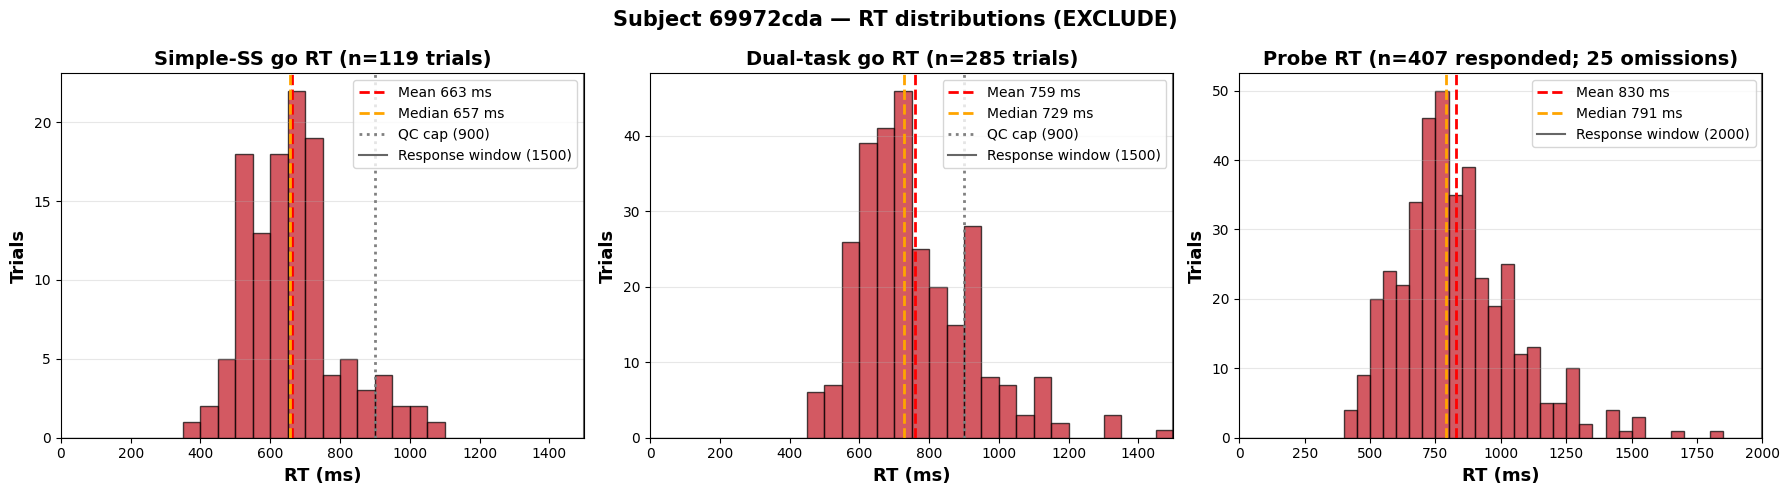

Subject 69a273aa  (full id: 69a273aa8ea44b93a7c318fa)
  WM dual-task reasons:
    - probe_response_accuracy (0.530) < min (0.55)
    - probe_wm4_response_accuracy (0.451) < min (0.55)
    - probe_wm6_response_accuracy (0.465) < min (0.55)


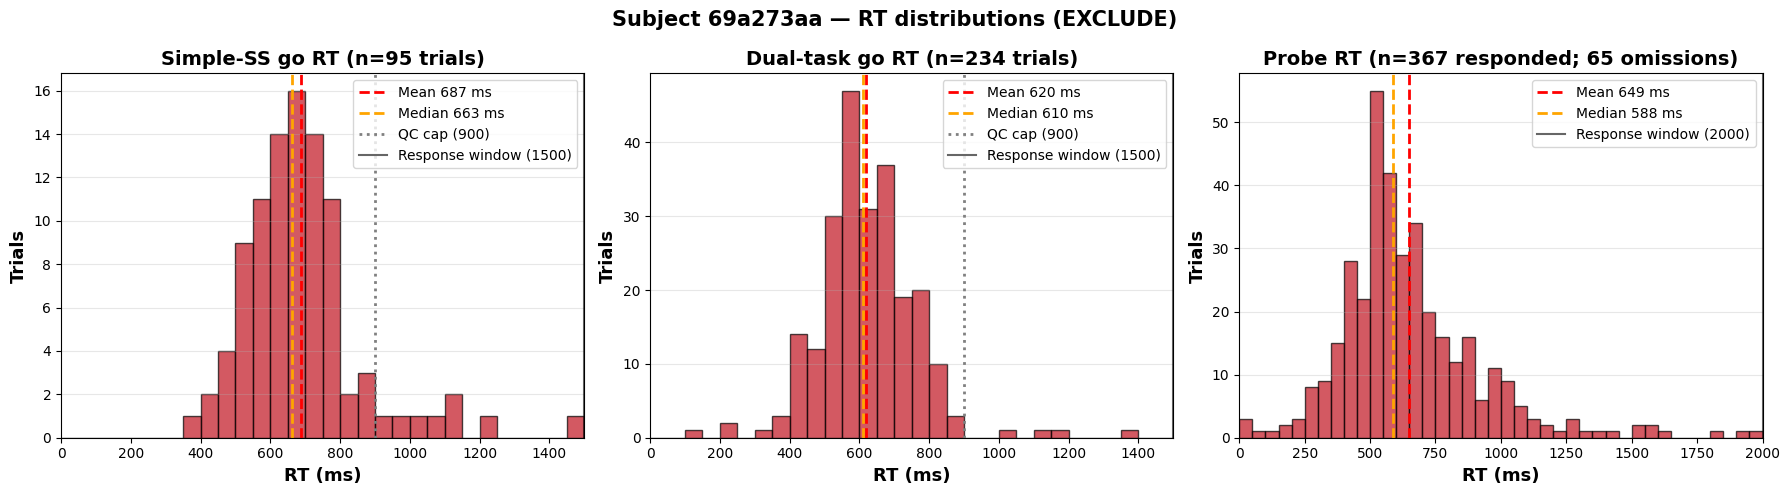

Subject 69a39642  (full id: 69a396424c59826d1a132598)
  Simple SS reasons:
    - go_choice_accuracy (0.333) < min (0.55)
    - stop_inhibition_success_rate (0.817) > max (0.75)
    - go_mean_rt (1170.600) > max (900.0)
    - go_omission_rate (0.625) > max (0.5)
    - stop_fail_rate [BINOMIAL TEST] (0.183) <= min (0.367)
  WM dual-task reasons:
    - dual_task_go_choice_accuracy (0.542) < min (0.55)
    - probe_response_accuracy (0.435) < min (0.55)
    - probe_wm2_response_accuracy (0.528) < min (0.55)
    - probe_wm4_response_accuracy (0.444) < min (0.55)
    - probe_wm6_response_accuracy (0.333) < min (0.55)


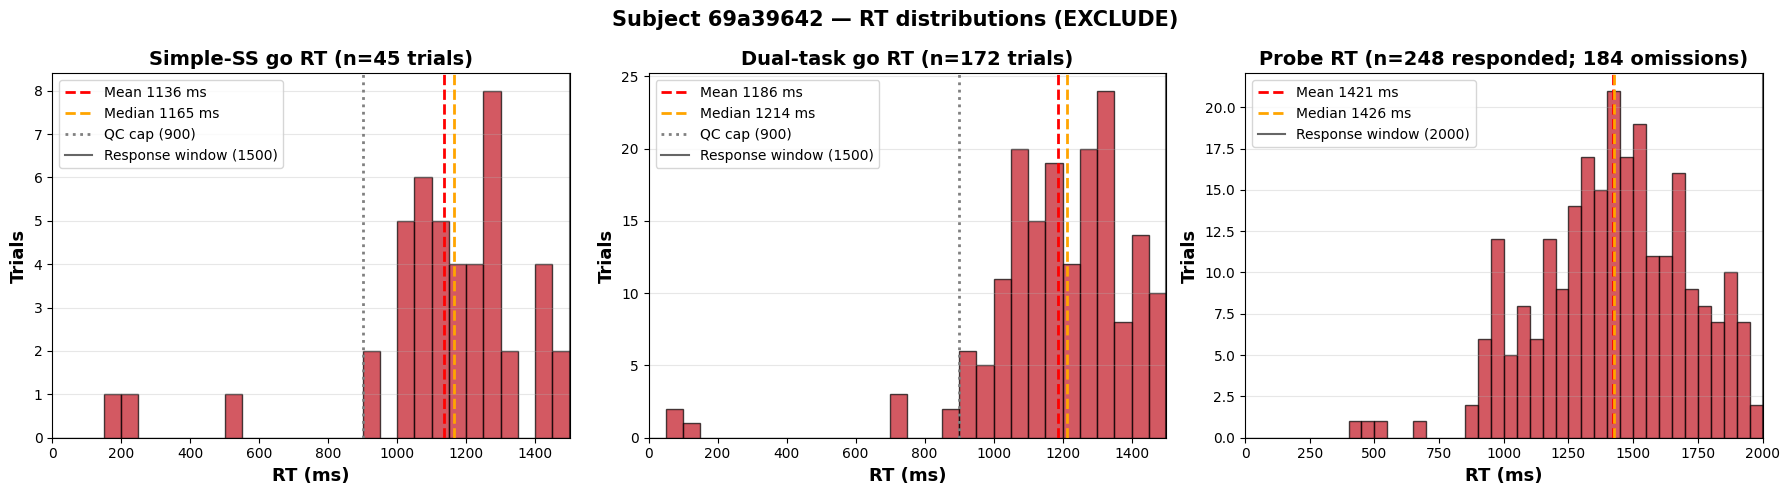

Subject 69a923b7  (full id: 69a923b771d0f5d664ef6578)
  WM dual-task reasons:
    - probe_wm6_response_accuracy (0.514) < min (0.55)


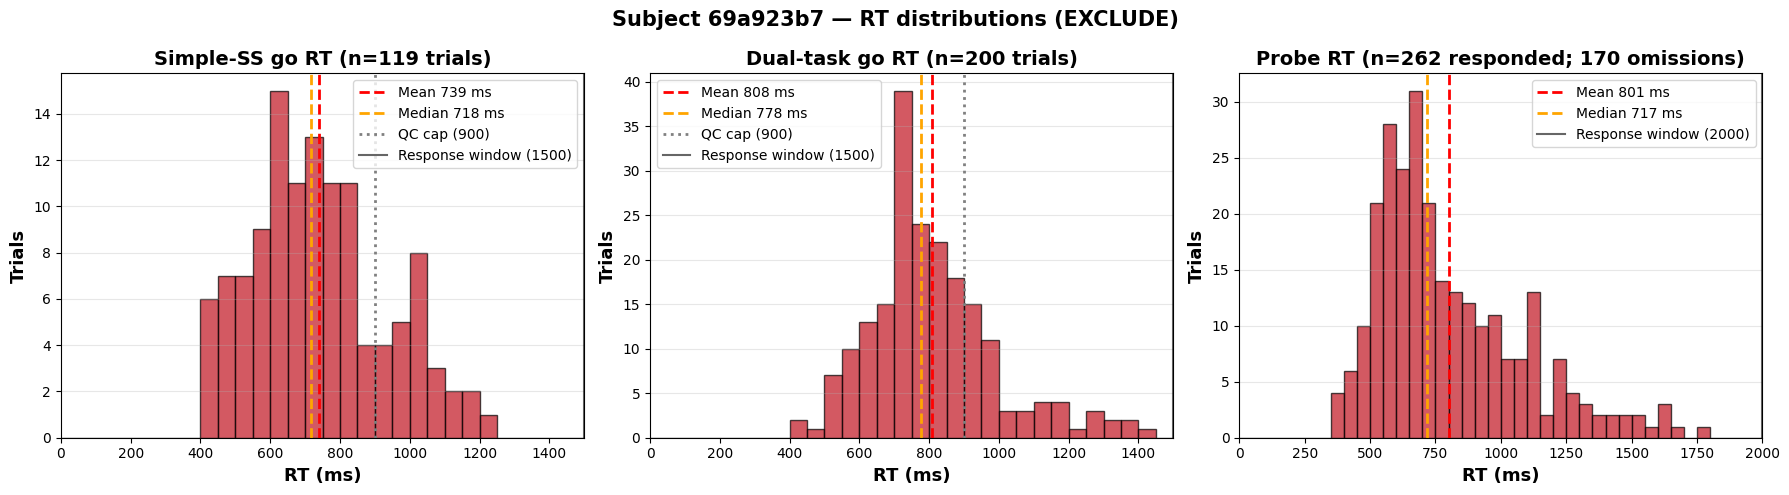

Subject 69c14cd2  (full id: 69c14cd22aaa811ba3f12587)
  WM dual-task reasons:
    - probe_wm6_response_accuracy (0.514) < min (0.55)


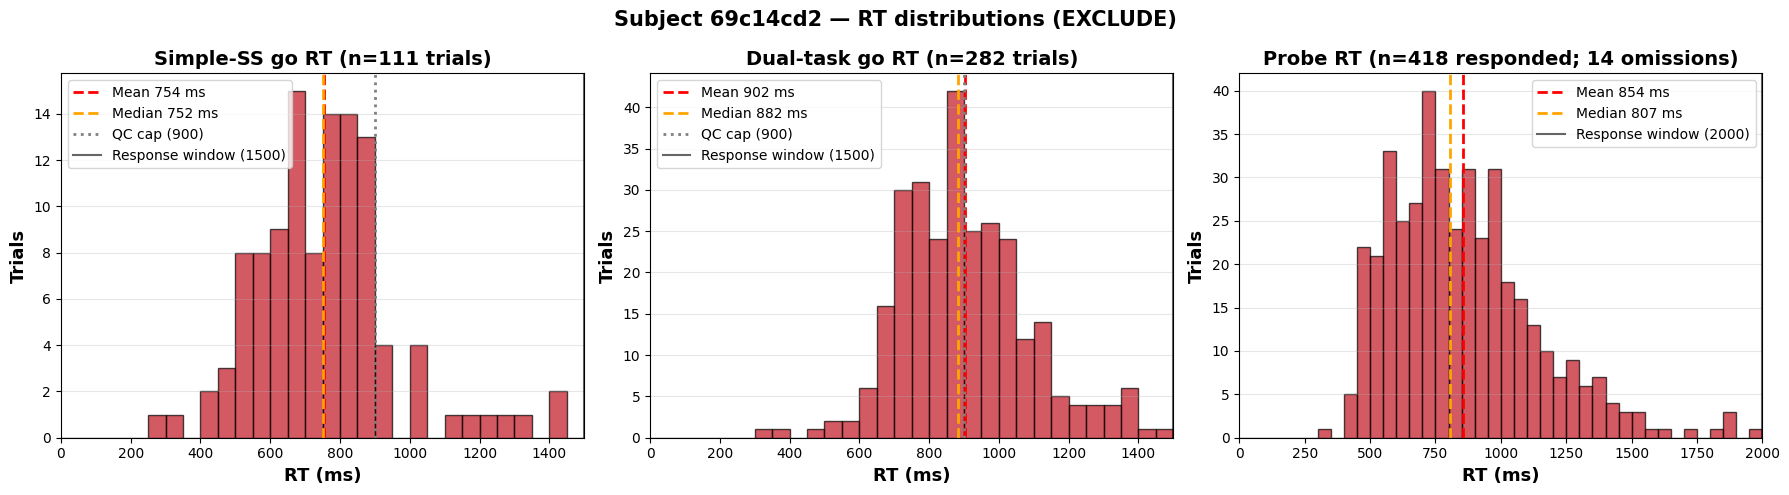

Subject 69c2b65e  (full id: 69c2b65ed4ba70b3995b5e4a)
  WM dual-task reasons:
    - incomplete_task (did not complete Stop Signal task)


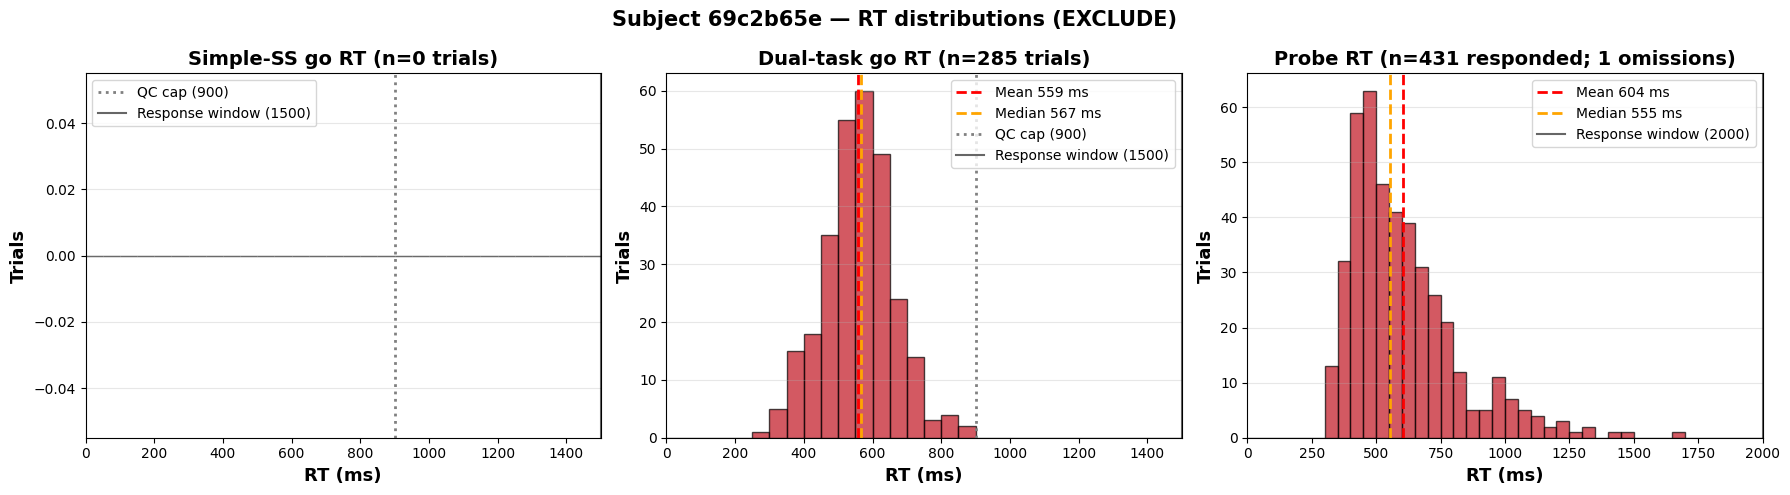

Subject 69cc5b99  (full id: 69cc5b991e26f316db82dd76)
  WM dual-task reasons:
    - dual_stop_fail_rate_wm2 [BINOMIAL TEST] (0.312) <= min (0.354)
    - dual_stop_fail_rate_wm4 [BINOMIAL TEST] (0.250) <= min (0.354)
    - dual_stop_fail_rate_wm6 [BINOMIAL TEST] (0.208) <= min (0.354)
    - dual_task_go_choice_accuracy (0.455) < min (0.55)
    - probe_response_accuracy (0.424) < min (0.55)
    - probe_wm2_response_accuracy (0.438) < min (0.55)
    - probe_wm4_response_accuracy (0.438) < min (0.55)
    - probe_wm6_response_accuracy (0.396) < min (0.55)
    - dual_task_go_omission_rate (0.531) > max (0.5)


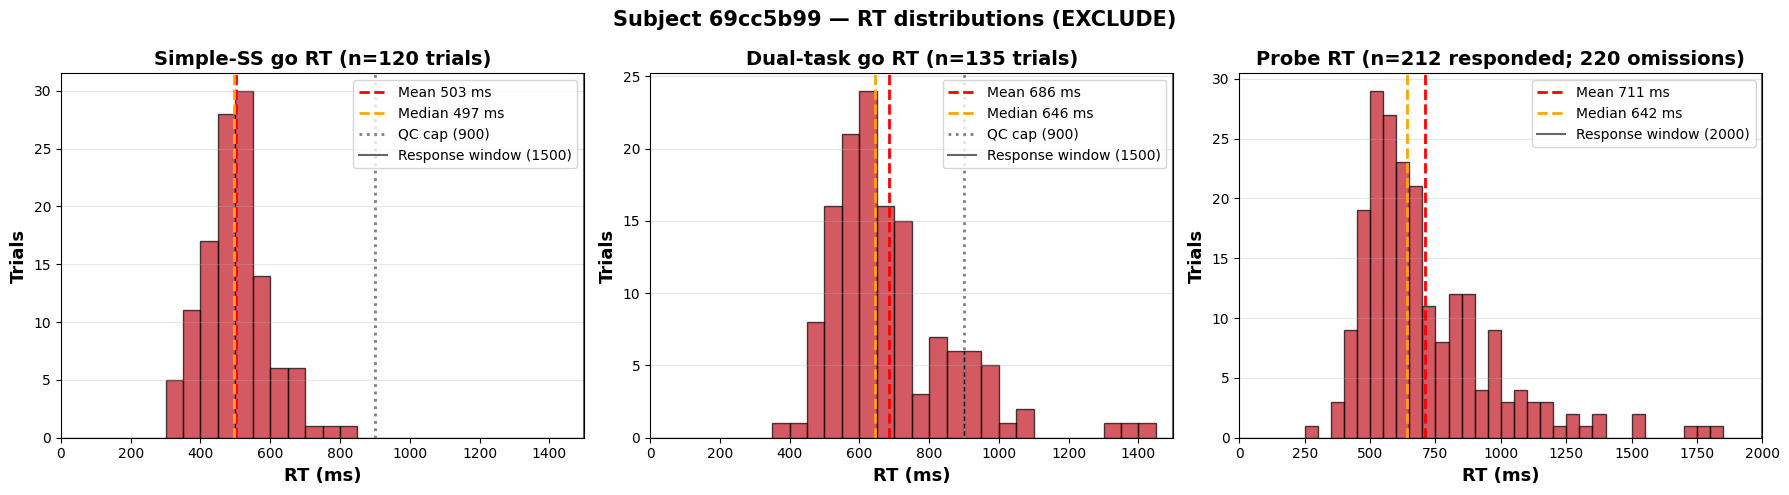

Subject 69dfe6b2  (full id: 69dfe6b26b573565aea6dac6)
  Simple SS reasons:
    - go_choice_accuracy (0.083) < min (0.55)
    - stop_inhibition_success_rate (0.850) > max (0.75)
    - go_omission_rate (0.842) > max (0.5)
    - stop_fail_rate [BINOMIAL TEST] (0.150) <= min (0.367)
  WM dual-task reasons:
    - dual_stop_fail_rate_wm2 [BINOMIAL TEST] (0.125) <= min (0.354)
    - dual_stop_fail_rate_wm4 [BINOMIAL TEST] (0.083) <= min (0.354)
    - dual_stop_fail_rate_wm6 [BINOMIAL TEST] (0.104) <= min (0.354)
    - dual_task_go_choice_accuracy (0.069) < min (0.55)
    - dual_task_stop_inhibition_success_rate (0.896) > max (0.75)
    - probe_response_accuracy (0.060) < min (0.55)
    - probe_wm2_response_accuracy (0.062) < min (0.55)
    - probe_wm4_response_accuracy (0.049) < min (0.55)
    - probe_wm6_response_accuracy (0.069) < min (0.55)
    - dual_task_go_omission_rate (0.882) > max (0.5)


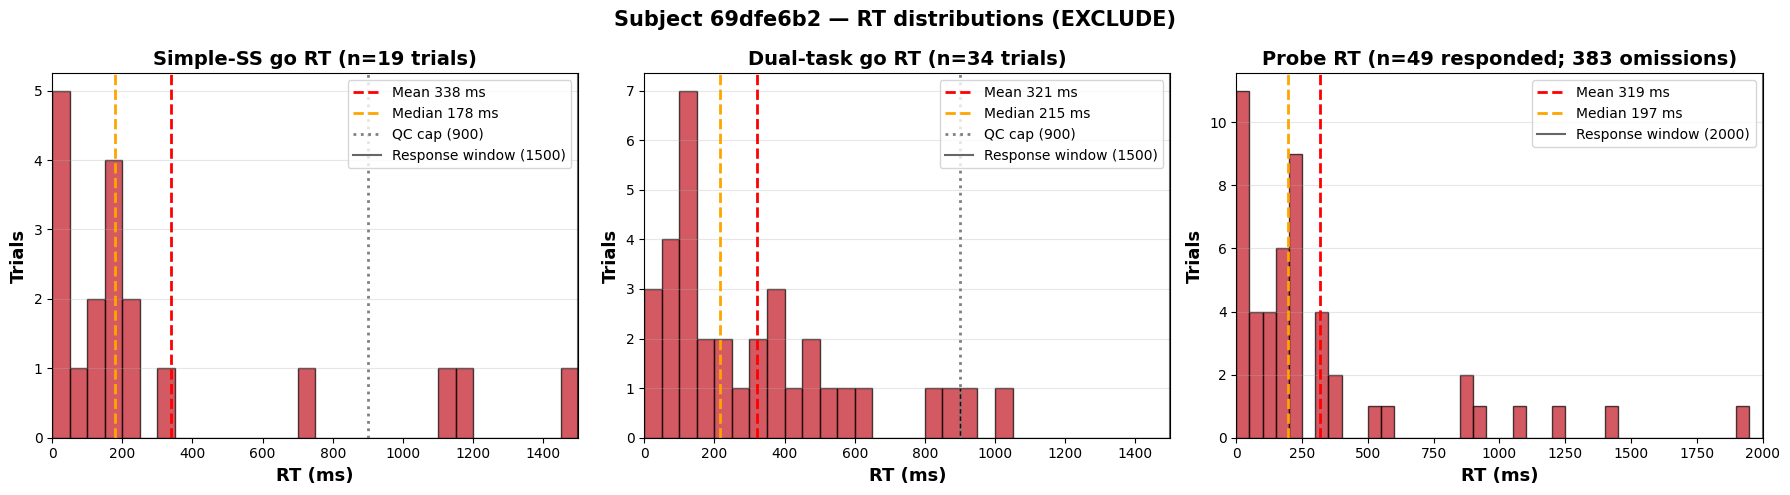

Subject 69e26ddc  (full id: 69e26ddcd33f0b34bcd31398)
  WM dual-task reasons:
    - incomplete_task (did not complete Stop Signal task)


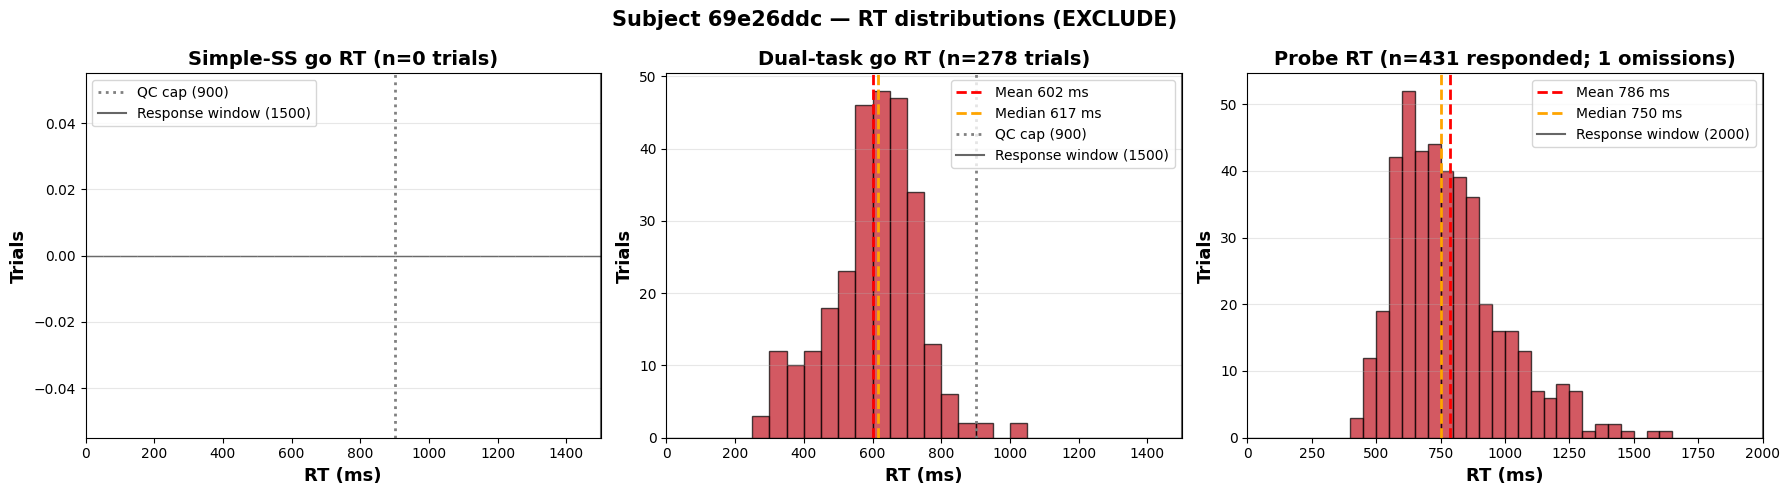

Subject 69e3dea6  (full id: 69e3dea6cfe3aeedec8f978b)
  Simple SS reasons:
    - go_choice_accuracy (0.492) < min (0.55)
    - stop_fail_rate [BINOMIAL TEST] (0.283) <= min (0.367)
  WM dual-task reasons:
    - probe_response_accuracy (0.104) < min (0.55)
    - probe_wm2_response_accuracy (0.167) < min (0.55)
    - probe_wm4_response_accuracy (0.090) < min (0.55)
    - probe_wm6_response_accuracy (0.056) < min (0.55)


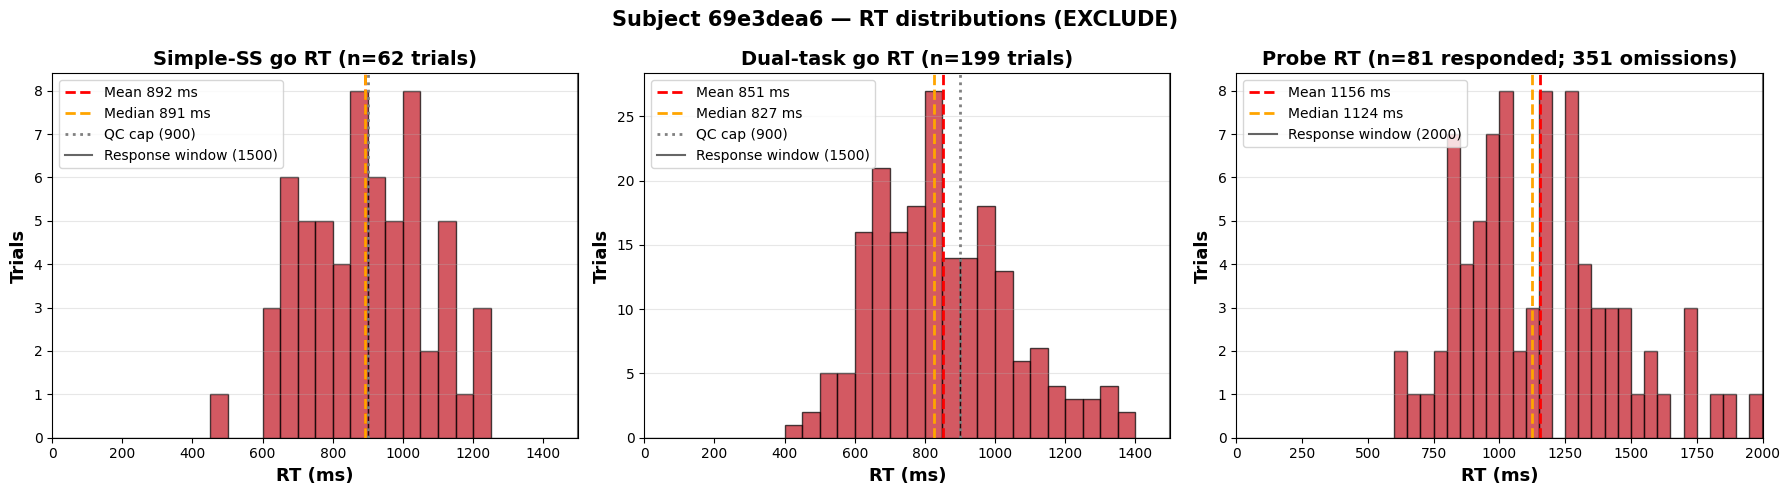

Subject 69e78b14  (full id: 69e78b1402bffcdbf274a661)
  Simple SS reasons:
    - go_mean_rt (1075.425) > max (900.0)
  WM dual-task reasons:
    - dual_stop_fail_rate_wm2 [BINOMIAL TEST] (0.333) <= min (0.354)
    - probe_response_accuracy (0.410) < min (0.55)
    - probe_wm2_response_accuracy (0.417) < min (0.55)
    - probe_wm4_response_accuracy (0.417) < min (0.55)
    - probe_wm6_response_accuracy (0.396) < min (0.55)


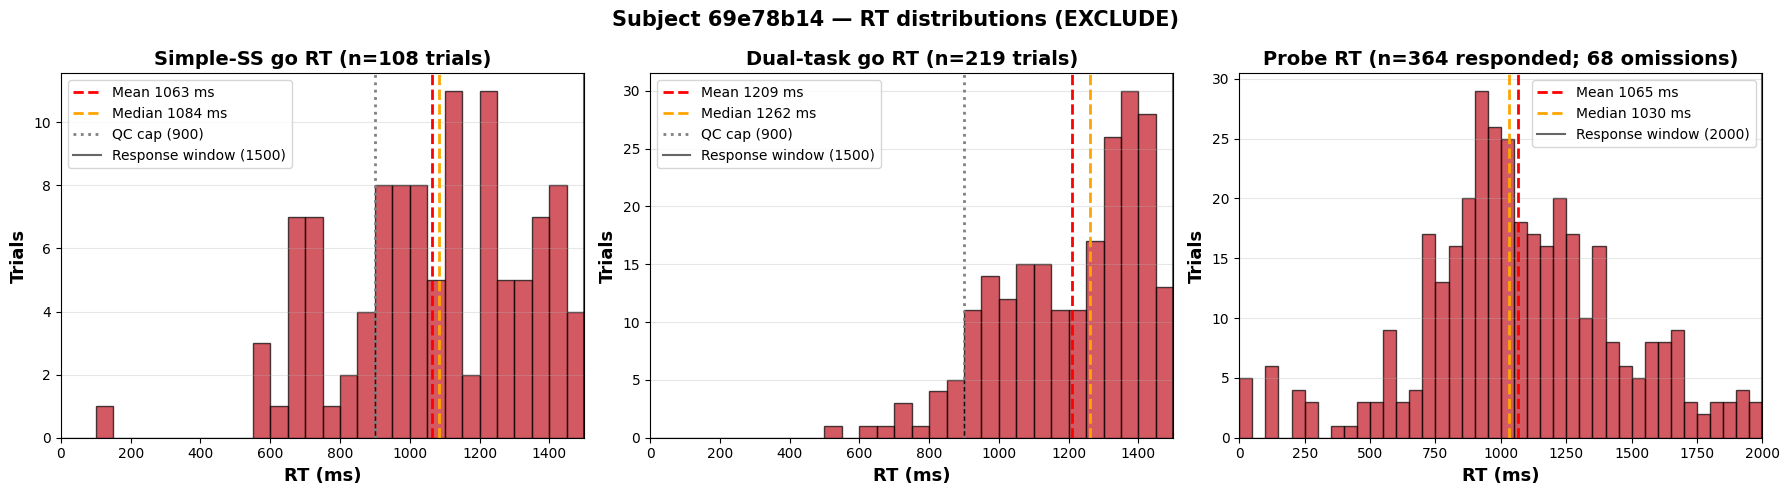

Subject 69e7ee66  (full id: 69e7ee6637e005bae61a12b2)
  WM dual-task reasons:
    - dual_task_n_go_trials (240.000) != required (288.0)
    - dual_task_n_stop_trials (120.000) != required (144.0)
    - dual_stop_fail_rate_wm4 [BINOMIAL TEST] (0.350) <= min (0.354)


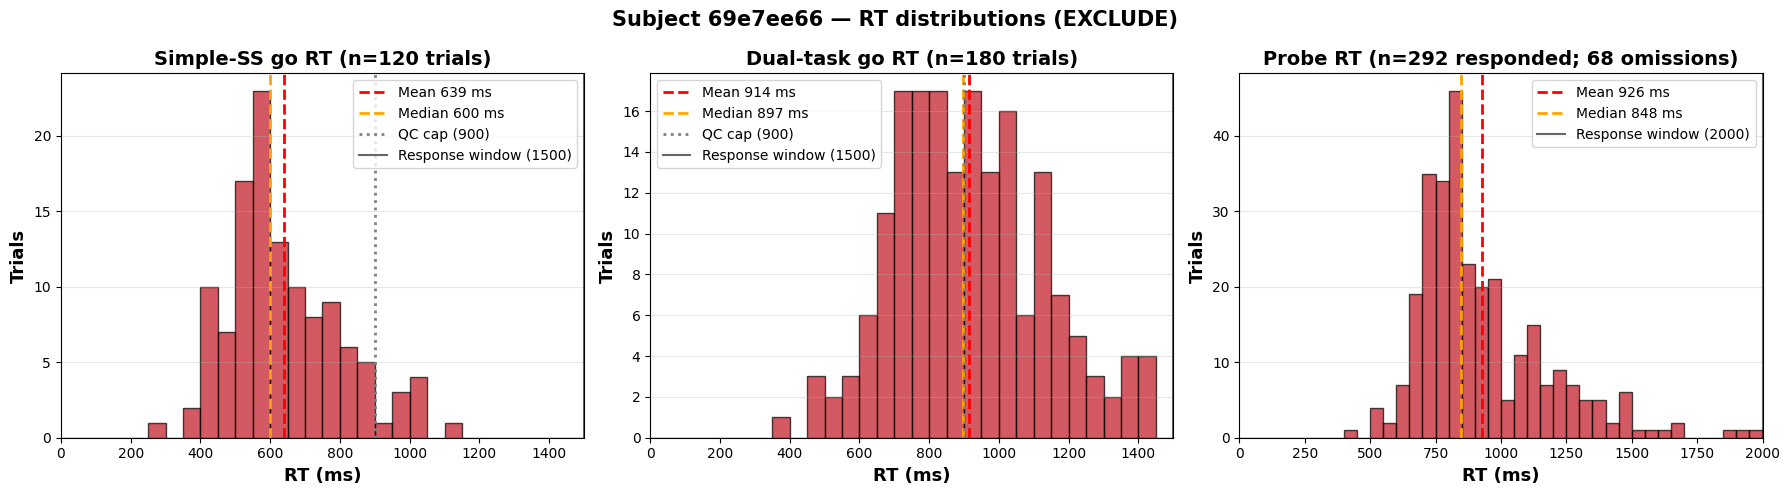

Subject 69e83b0b  (full id: 69e83b0bb39532367ff2e96d)
  WM dual-task reasons:
    - probe_response_accuracy (0.366) < min (0.55)
    - probe_wm2_response_accuracy (0.431) < min (0.55)
    - probe_wm4_response_accuracy (0.333) < min (0.55)
    - probe_wm6_response_accuracy (0.333) < min (0.55)


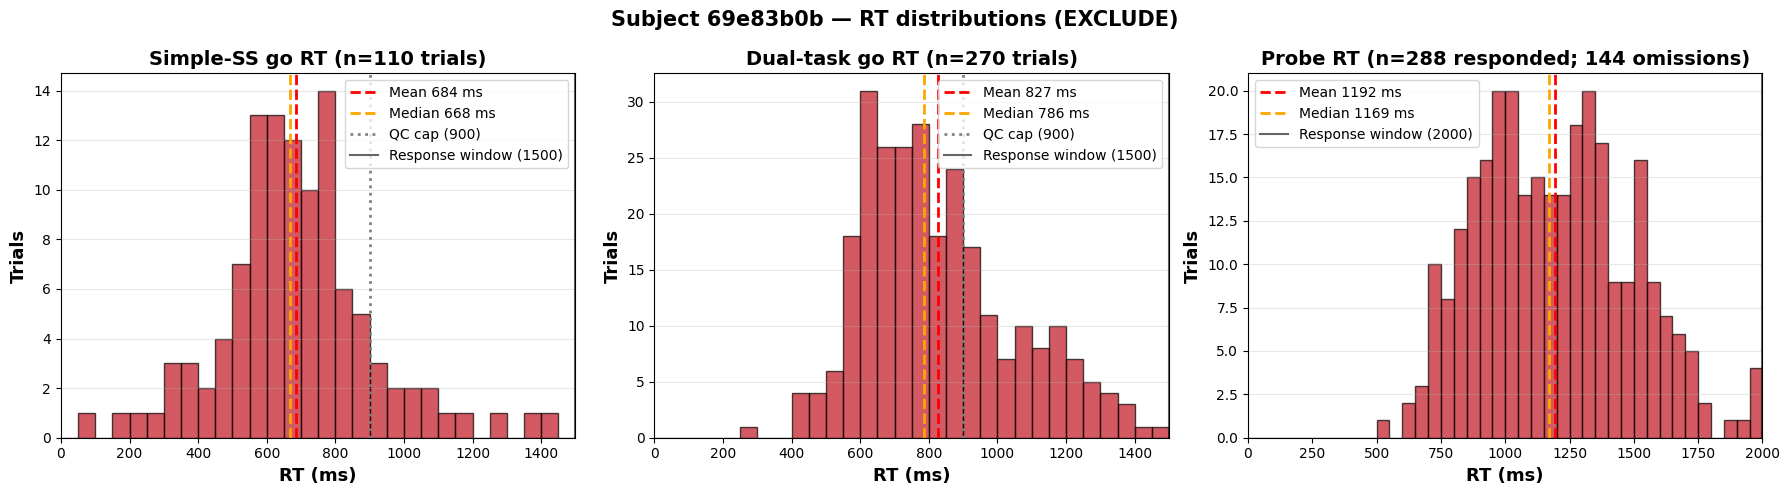

In [6]:
# === PER-EXCLUDED-SUBJECT DETAIL ===
# Fixed response-window caps (from task config):
#   Simple-SS go trial_duration   = 1500 ms
#   Dual-task stop_trial_duration = 1500 ms
#   Probe memory_recognition_trial_duration = 2000 ms
# Use these as both the x-axis upper limit and the upper edge of the last bin
# so distributions are directly comparable across subjects.
GO_CAP = 1500       # ms — same for simple SS and dual-task go trials
PROBE_CAP = 2000    # ms — memory recognition trial duration

go_bins = np.linspace(0, GO_CAP, 31)        # 30 bins of 50 ms width
probe_bins = np.linspace(0, PROBE_CAP, 41)  # 40 bins of 50 ms width

excluded_ids = sorted(flagged_ids)
ss_reasons = dict(zip(flag_ss['prolific_id'], flag_ss['exclusion_reasons']))
wm_reasons = dict(zip(flag_wm['prolific_id'], flag_wm['exclusion_reasons']))

trials_wm['stop_trial_rt'] = pd.to_numeric(trials_wm['stop_trial_rt'], errors='coerce')
trials_ss['trial_rt'] = pd.to_numeric(trials_ss['trial_rt'], errors='coerce')

for pid in excluded_ids:
    short = pid[:8]
    print('='*70)
    print(f"Subject {short}  (full id: {pid})")
    print('='*70)
    if pid in ss_reasons:
        print('  Simple SS reasons:')
        for r in ss_reasons[pid].split(';'):
            print(f"    - {r.strip()}")
    if pid in wm_reasons:
        print('  WM dual-task reasons:')
        for r in wm_reasons[pid].split(';'):
            print(f"    - {r.strip()}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # (a) simple-SS go RT distribution
    ss_sub = trials_ss[(trials_ss['participant_id']==pid) & (trials_ss['trial_condition']=='go')]
    rts = ss_sub['trial_rt'].dropna()
    # Clip rare overshoots so they land in the final bin instead of being dropped
    rts_plot = rts.clip(upper=GO_CAP)
    axes[0].hist(rts_plot, bins=go_bins, color=STATUS_COLORS['EXCLUDE'], alpha=0.7, edgecolor='black')
    if len(rts):
        axes[0].axvline(rts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean {rts.mean():.0f} ms')
        axes[0].axvline(rts.median(), color='orange', linestyle='--', linewidth=2, label=f'Median {rts.median():.0f} ms')
    axes[0].axvline(900, color='gray', linestyle=':', linewidth=2, label='QC cap (900)')
    axes[0].axvline(GO_CAP, color='black', linestyle='-', linewidth=1.5, alpha=0.6, label=f'Response window ({GO_CAP})')
    axes[0].set_xlim(0, GO_CAP)
    axes[0].set_title(f'Simple-SS go RT (n={len(rts)} trials)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('RT (ms)', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Trials', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].legend(fontsize=10)

    # (b) dual-task go RT distribution (stop_trial_SS_trial_type == 'go')
    wm_sub = trials_wm[(trials_wm['participant_id']==pid) & (trials_wm['stop_trial_SS_trial_type']=='go')]
    rts = wm_sub['stop_trial_rt'].dropna()
    rts_plot = rts.clip(upper=GO_CAP)
    axes[1].hist(rts_plot, bins=go_bins, color=STATUS_COLORS['EXCLUDE'], alpha=0.7, edgecolor='black')
    if len(rts):
        axes[1].axvline(rts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean {rts.mean():.0f} ms')
        axes[1].axvline(rts.median(), color='orange', linestyle='--', linewidth=2, label=f'Median {rts.median():.0f} ms')
    axes[1].axvline(900, color='gray', linestyle=':', linewidth=2, label='QC cap (900)')
    axes[1].axvline(GO_CAP, color='black', linestyle='-', linewidth=1.5, alpha=0.6, label=f'Response window ({GO_CAP})')
    axes[1].set_xlim(0, GO_CAP)
    axes[1].set_title(f'Dual-task go RT (n={len(rts)} trials)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('RT (ms)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Trials', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].legend(fontsize=10)

    # (c) probe RT distribution (responses only — omissions excluded since RT is NaN)
    probe_sub = trials_wm[(trials_wm['participant_id']==pid)]
    rts = probe_sub['memory_recognition_rt'].dropna()
    n_total_probes = len(probe_sub.dropna(subset=['memory_recognition_correct_trial']))
    n_omissions = n_total_probes - len(rts)
    rts_plot = rts.clip(upper=PROBE_CAP)
    axes[2].hist(rts_plot, bins=probe_bins, color=STATUS_COLORS['EXCLUDE'], alpha=0.7, edgecolor='black')
    if len(rts):
        axes[2].axvline(rts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean {rts.mean():.0f} ms')
        axes[2].axvline(rts.median(), color='orange', linestyle='--', linewidth=2, label=f'Median {rts.median():.0f} ms')
    axes[2].axvline(PROBE_CAP, color='black', linestyle='-', linewidth=1.5, alpha=0.6, label=f'Response window ({PROBE_CAP})')
    axes[2].set_xlim(0, PROBE_CAP)
    axes[2].set_title(f'Probe RT (n={len(rts)} responded; {n_omissions} omissions)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('RT (ms)', fontsize=13, fontweight='bold')
    axes[2].set_ylabel('Trials', fontsize=13, fontweight='bold')
    axes[2].grid(True, alpha=0.3, axis='y')
    axes[2].legend(fontsize=10)

    plt.suptitle(f'Subject {short} — RT distributions (EXCLUDE)', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()
